In [ ]:
# ============================================
# 10. 연령대별 고유 연관상품 (다른 연령대에서는 잘 안 나타나는 규칙)
# ============================================

print("=" * 120)
print("【연령대별 고유 연관상품】")
print("  다른 연령대 대비 해당 연령대에서 Lift가 특별히 높은 규칙")
print("=" * 120)

# 모든 연령대의 규칙을 하나로 합치기
all_age_rules = []
for age_group, rules_age in age_small_results.items():
    temp = rules_age.copy()
    temp['age_group'] = age_group
    temp['pair'] = temp['antecedents'].apply(lambda x: tuple(sorted(list(x)))) + temp['consequents'].apply(lambda x: tuple(sorted(list(x))))
    temp['pair_key'] = temp.apply(lambda r: tuple(sorted([tuple(sorted(list(r['antecedents']))), tuple(sorted(list(r['consequents'])))])), axis=1)
    all_age_rules.append(temp)

all_rules_df = pd.concat(all_age_rules, ignore_index=True)

# 각 상품쌍별 연령대별 Lift 피벗
pivot_lift = all_rules_df.pivot_table(index='pair_key', columns='age_group', values='lift', aggfunc='first')

for age_group in age_groups:
    if age_group not in pivot_lift.columns:
        continue
    
    # 해당 연령대의 Lift가 다른 연령대의 평균 Lift보다 높은 규칙 찾기
    other_ages = [a for a in age_groups if a != age_group and a in pivot_lift.columns]
    if not other_ages:
        continue
    
    pivot_lift[f'{age_group}_diff'] = pivot_lift[age_group] - pivot_lift[other_ages].mean(axis=1)
    
    # 차이가 큰 상위 5개
    top_unique = pivot_lift.dropna(subset=[age_group]).nlargest(5, f'{age_group}_diff')
    
    if len(top_unique) > 0:
        print(f"\n【{age_group}대 고유 연관상품 TOP 5】")
        print("-" * 80)
        
        for rank, (pair_key, row) in enumerate(top_unique.iterrows(), 1):
            # pair_key에서 상품명 추출
            items_a = ', '.join(list(pair_key[0])) if isinstance(pair_key[0], tuple) else str(pair_key[0])
            items_b = ', '.join(list(pair_key[1])) if isinstance(pair_key[1], tuple) else str(pair_key[1])
            
            lift_val = row[age_group]
            other_avg = row[other_ages].mean()
            diff = row[f'{age_group}_diff']
            
            print(f"  {rank}. {items_a} ↔ {items_b}")
            print(f"     {age_group}대 Lift: {lift_val:.4f} | 타 연령대 평균 Lift: {other_avg:.4f} | 차이: +{diff:.4f}")
    
    # 임시 컬럼 제거
    pivot_lift.drop(columns=[f'{age_group}_diff'], inplace=True)

print(f"\n{'=' * 120}")

In [ ]:
# ============================================
# 9. 연령대별 연관상품 추천 요약표
# ============================================

print("=" * 120)
print("【연령대별 연관상품 추천 요약】")
print("=" * 120)
print("(각 연령대에서 Lift가 높은 상위 연관 상품 쌍을 추천 상품으로 제시)")
print()

small_to_middle = df.drop_duplicates(subset='ItemSmallName')[['ItemSmallName', 'ItemMiddleName']].set_index('ItemSmallName')['ItemMiddleName'].to_dict()

recommendation_data = []

for age_group in age_groups:
    if age_group in age_small_results:
        rules_age = age_small_results[age_group]
        top_rules = rules_age.head(10)
        
        print(f"\n{'━' * 60}")
        print(f"  {age_group}대 추천 연관상품")
        print(f"{'━' * 60}")
        
        for rank, (_, row) in enumerate(top_rules.iterrows(), 1):
            ant = ', '.join(list(row['antecedents']))
            cons = ', '.join(list(row['consequents']))
            ant_mid = ', '.join([small_to_middle.get(i, '?') for i in list(row['antecedents'])])
            cons_mid = ', '.join([small_to_middle.get(i, '?') for i in list(row['consequents'])])
            
            print(f"  {rank:2d}. {ant}({ant_mid}) 구매 시 → {cons}({cons_mid}) 추천")
            print(f"      Confidence: {row['confidence']:.1%} | Lift: {row['lift']:.4f}")
            
            recommendation_data.append({
                '연령대': f'{age_group}대',
                '순위': rank,
                '상품A': ant,
                '상품A_중분류': ant_mid,
                '상품B': cons,
                '상품B_중분류': cons_mid,
                'Support': round(row['support'], 4),
                'Confidence': round(row['confidence'], 4),
                'Lift': round(row['lift'], 4)
            })

# 추천 데이터프레임 생성
recommendation_df = pd.DataFrame(recommendation_data)
print(f"\n\n{'=' * 120}")
print(f"총 {len(recommendation_df)}개 연관상품 추천 규칙 도출 완료")
print(f"{'=' * 120}")

In [ ]:
# ============================================
# 8. 연령대별 소분류 연관분석 시각화
# ============================================

if age_small_results:
    num_ages = len(age_small_results)
    fig, axes = plt.subplots(1, num_ages, figsize=(6*num_ages, 8))
    
    if num_ages == 1:
        axes = [axes]
    
    for idx, (age_group, rules_age) in enumerate(age_small_results.items()):
        ax = axes[idx]
        top5 = rules_age.head(10)
        
        labels = []
        for x, y in zip(top5['antecedents'], top5['consequents']):
            ant = ', '.join(list(x))
            cons = ', '.join(list(y))
            if len(ant) > 10:
                ant = ant[:10] + '...'
            if len(cons) > 10:
                cons = cons[:10] + '...'
            labels.append(f"{ant}\n→ {cons}")
        
        colors = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, len(top5)))
        bars = ax.barh(range(len(top5)), top5['lift'].values, color=colors, edgecolor='black', linewidth=0.5)
        ax.set_yticks(range(len(top5)))
        ax.set_yticklabels(labels, fontsize=8)
        ax.set_xlabel('Lift', fontsize=10)
        ax.set_title(f'{age_group}대 - 소분류 Lift TOP 10', fontsize=11, fontweight='bold')
        ax.invert_yaxis()
        ax.grid(alpha=0.3, axis='x')
        ax.axvline(x=1, color='gray', linestyle='--', alpha=0.5)
        
        # Lift 값 표시
        for bar, val in zip(bars, top5['lift'].values):
            ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
                   va='center', fontsize=7, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('age_group_small_association.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✓ 연령대별 소분류 연관분석 시각화 저장: age_group_small_association.png")

In [ ]:
# ============================================
# 7. 연령대별 소분류 연관상품 TOP 15
# ============================================

print("=" * 120)
print("【연령대별 소분류 연관상품 TOP 15】(Lift 기준 정렬)")
print("=" * 120)

for age_group in age_groups:
    if age_group in age_small_results:
        rules_age = age_small_results[age_group]
        
        if len(rules_age) > 0:
            top_n = rules_age.head(15).copy()
            top_n['소분류A'] = top_n['antecedents'].apply(lambda x: ', '.join(list(x)))
            top_n['소분류B'] = top_n['consequents'].apply(lambda x: ', '.join(list(x)))
            
            # 소분류가 속한 중분류 정보 추가
            small_to_middle = df.drop_duplicates(subset='ItemSmallName')[['ItemSmallName', 'ItemMiddleName']].set_index('ItemSmallName')['ItemMiddleName'].to_dict()
            top_n['중분류A'] = top_n['antecedents'].apply(lambda x: ', '.join([small_to_middle.get(i, '?') for i in list(x)]))
            top_n['중분류B'] = top_n['consequents'].apply(lambda x: ', '.join([small_to_middle.get(i, '?') for i in list(x)]))
            
            print(f"\n【{age_group}대】규칙 {len(rules_age)}개 중 상위 15개")
            print("-" * 120)
            
            result_table = top_n[['소분류A', '중분류A', '소분류B', '중분류B', 'support', 'confidence', 'lift']].reset_index(drop=True)
            result_table.index = result_table.index + 1
            result_table.columns = ['소분류 A', '(중분류)', '소분류 B', '(중분류)', 'Support', 'Confidence', 'Lift']
            
            result_table['Support'] = result_table['Support'].apply(lambda x: f'{x:.4f}')
            result_table['Confidence'] = result_table['Confidence'].apply(lambda x: f'{x:.1%}')
            result_table['Lift'] = result_table['Lift'].apply(lambda x: f'{x:.4f}')
            
            print(result_table.to_string())
            print()
    else:
        print(f"\n【{age_group}대】규칙이 없습니다.\n")

print("=" * 120)

In [ ]:
# ============================================
# 6. 연령대별 소분류 연관분석 (드릴다운)
# ============================================

age_groups = sorted(df['AgeGroup'].unique())
age_small_results = {}

print("=" * 120)
print("【연령대별 소분류 연관분석 (드릴다운)】")
print("=" * 120)

for age_group in age_groups:
    age_df = df[df['AgeGroup'] == age_group]
    
    # 고객별 소분류 구매 리스트
    age_products = age_df.groupby('idUser')['ItemSmallName'].apply(list).reset_index()
    age_products.columns = ['idUser', 'products']
    
    # 거래 데이터 인코딩
    te_age = TransactionEncoder()
    te_age_ary = te_age.fit(age_products['products']).transform(age_products['products'])
    df_age_encoded = pd.DataFrame(te_age_ary, columns=te_age.columns_)
    
    print(f"\n【{age_group}대】고객수: {len(age_products)}, 소분류 종류: {len(df_age_encoded.columns)}")
    
    # Apriori (소분류는 항목이 많으므로 support를 낮게 설정)
    frequent_itemsets_age = apriori(df_age_encoded, min_support=0.05, use_colnames=True, max_len=2)
    
    if len(frequent_itemsets_age) > 0:
        rules_age = association_rules(frequent_itemsets_age, metric="confidence", min_threshold=0.3)
        
        if len(rules_age) > 0:
            rules_age = rules_age.sort_values('lift', ascending=False)
            
            # 중복 제거
            rules_age_dedup = rules_age.copy()
            rules_age_dedup['A'] = rules_age_dedup['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
            rules_age_dedup['B'] = rules_age_dedup['consequents'].apply(lambda x: ', '.join(sorted(list(x))))
            rules_age_dedup['pair_key'] = rules_age_dedup.apply(
                lambda r: tuple(sorted([r['A'], r['B']])), axis=1
            )
            rules_age_dedup = rules_age_dedup.drop_duplicates(subset='pair_key', keep='first')
            rules_age_dedup = rules_age_dedup.drop(columns=['A', 'B', 'pair_key'])
            
            age_small_results[age_group] = rules_age_dedup
            
            print(f"  빈번한 항목집합: {len(frequent_itemsets_age)}개, 규칙(중복제거): {len(rules_age_dedup)}개")
        else:
            print(f"  규칙 없음 (confidence 0.3 이상)")
    else:
        print(f"  빈번한 항목집합 없음 (support 0.05 이상)")

In [1]:
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.style as style
import numpy as np
import pandas as pd

import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway
import datetime
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

# 맑은 고딕 적용
matplotlib.rc("font", family = "AppleGothic")
# 음수 표시
matplotlib.rc("axes", unicode_minus = False)

In [3]:
df = pd.read_csv("df_merged.csv", encoding="cp949")
df = df.dropna()
df.head()

,idUser,idOrder,OrderDT,ItemCode,Price,DeliveryDT,OrderYear,OrderMonth,OrderDay,OrderHour,...,ItemSmallCode,ItemSmallName,ItemName,PriceMin,PriceMax,Gender,Age,FamilyCount,MemberYN,AgeGroup
0,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M17-S0530-1024,33310,2023-01-07 06:24:00,2023,1,6,17,...,S0530,전복,완도 활전복 1kg 중 22-25미,33160.0,37070.0,여성,26,2,Y,20
1,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M21-S0540-1082,3780,2023-01-07 06:24:00,2023,1,6,17,...,S0540,즉석,동원 양반 차돌된장찌개 (460G),3690.0,3970.0,여성,26,2,Y,20
2,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M15-S0140-1311,22520,2023-01-07 06:24:00,2023,1,6,17,...,S0140,냉동,오뚜기 듬뿍 새우볶음밥450g (2인분) x 5봉지 /,22150.0,23150.0,여성,26,2,Y,20
3,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M12-S0350-1035,21630,2023-01-07 06:24:00,2023,1,6,17,...,S0350,사과,[산지직송] 새콤달콤 부사 사과 5kg (13과내),20810.0,23030.0,여성,26,2,Y,20
4,U10001,U10001-O2023-1003,2023-01-13 16:50:14,L4-M12-S0640-1057,11700,2023-01-14 06:28:00,2023,1,13,16,...,S0640,토마토,스테비아 방울 토마토 라루 토망고 1kg,11640.0,13020.0,여성,26,2,Y,20


# 중분류 데이터 탐색

중분류 카테고리 수: 14
소분류 카테고리 수: 58

→ 중분류는 소분류 대비 항목 수가 적어 연관규칙의 support가 높아지고, 더 안정적인 패턴 발견 가능

【중분류별 거래건수 (상위 20개)】
ItemMiddleName
과일    181625
채소    161894
수산    158760
곡물     71083
냉동     65633
축산     49448
양념     35594
신선     34781
즉석     32337
커피     28434
과자     17132
음료      9115
생수      4241
탄산      4024


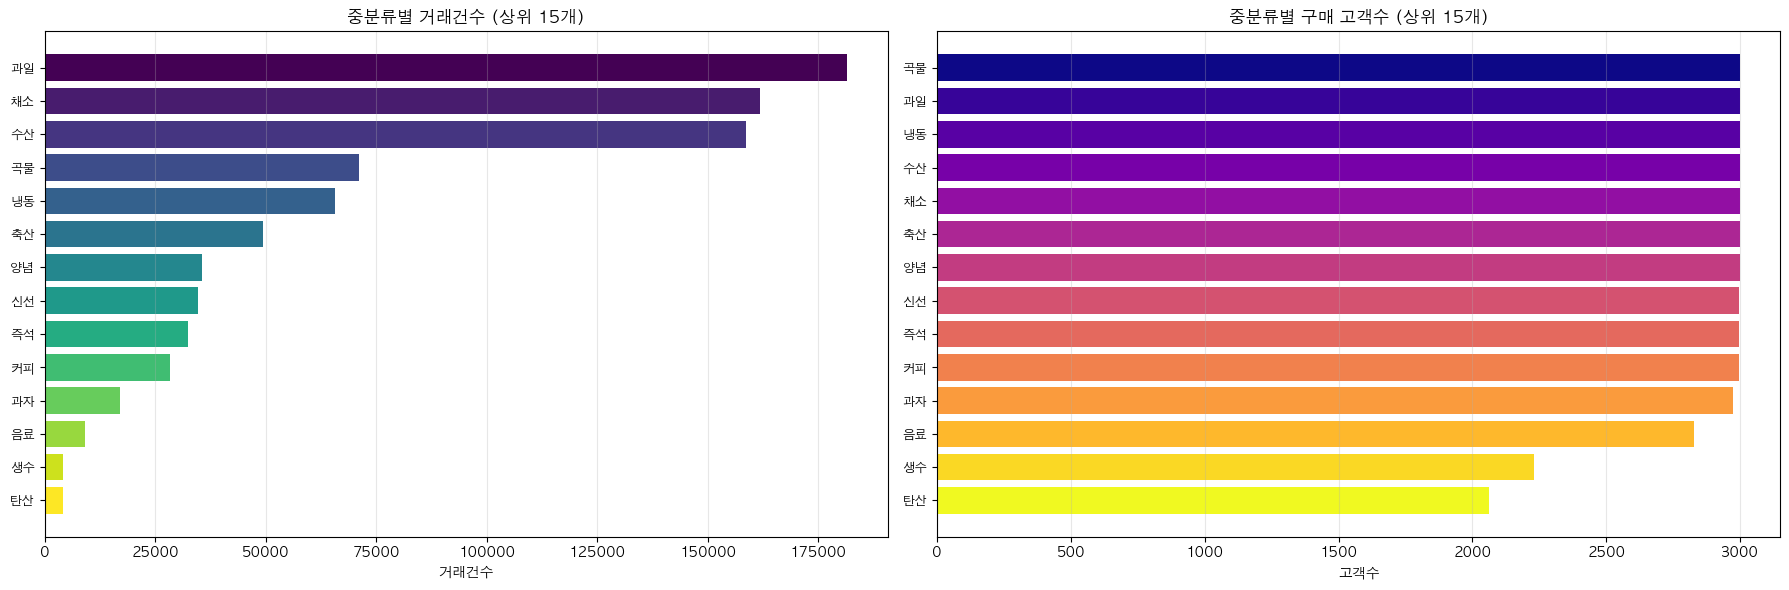

In [4]:
# ============================================
# 중분류 카테고리 분포 확인
# ============================================

print(f"중분류 카테고리 수: {df['ItemMiddleName'].nunique()}")
print(f"소분류 카테고리 수: {df['ItemSmallName'].nunique()}")
print(f"\n→ 중분류는 소분류 대비 항목 수가 적어 연관규칙의 support가 높아지고, 더 안정적인 패턴 발견 가능\n")

# 중분류별 거래건수
middle_counts = df['ItemMiddleName'].value_counts()
print("=" * 60)
print("【중분류별 거래건수 (상위 20개)】")
print("=" * 60)
print(middle_counts.head(20).to_string())

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 상위 15개 중분류 거래건수
ax = axes[0]
top15 = middle_counts.head(15)
ax.barh(range(len(top15)), top15.values, color=plt.cm.viridis(np.linspace(0, 1, len(top15))))
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15.index, fontsize=9)
ax.set_xlabel('거래건수')
ax.set_title('중분류별 거래건수 (상위 15개)', fontweight='bold')
ax.invert_yaxis()
ax.grid(alpha=0.3, axis='x')

# 중분류별 고객수
ax = axes[1]
middle_customers = df.groupby('ItemMiddleName')['idUser'].nunique().sort_values(ascending=False).head(15)
ax.barh(range(len(middle_customers)), middle_customers.values, color=plt.cm.plasma(np.linspace(0, 1, len(middle_customers))))
ax.set_yticks(range(len(middle_customers)))
ax.set_yticklabels(middle_customers.index, fontsize=9)
ax.set_xlabel('고객수')
ax.set_title('중분류별 구매 고객수 (상위 15개)', fontweight='bold')
ax.invert_yaxis()
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# 중분류 연관분석

In [5]:
# ============================================
# 1. 고객별 연관분석 (중분류 기준)
# ============================================

# 고객별로 구매한 중분류 리스트 생성
customer_products = df.groupby('idUser')['ItemMiddleName'].apply(list).reset_index()
customer_products.columns = ['idUser', 'products']

print(f"총 고객수: {len(customer_products)}")
print(f"평균 구매 중분류 수: {customer_products['products'].apply(len).mean():.2f}")

# 거래 데이터 인코딩 (One-hot encoding)
te = TransactionEncoder()
te_ary = te.fit(customer_products['products']).transform(customer_products['products'])
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"중분류 종류: {len(df_encoded.columns)}")
print(f"분석 시작...")

# Apriori 알고리즘 (최소 지지도 3%, 최대 길이 3)
frequent_itemsets = apriori(df_encoded, min_support=0.03, use_colnames=True, max_len=3)

print(f"✓ 발견된 빈번한 항목집합: {len(frequent_itemsets)}개")

# 연관성 규칙 생성
if len(frequent_itemsets) > 0:
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)
    
    if len(rules) > 0:
        # Lift 값으로 정렬
        rules = rules.sort_values('lift', ascending=False)
        
        # 중복 제거 (같은 상품 쌍 중 Lift가 높은 방향 유지)
        rules_display = rules.copy()
        rules_display['상품A_temp'] = rules_display['antecedents'].apply(lambda x: ', '.join(list(x)))
        rules_display['상품B_temp'] = rules_display['consequents'].apply(lambda x: ', '.join(list(x)))
        rules_display['pair_key'] = rules_display.apply(
            lambda r: tuple(sorted([r['상품A_temp'], r['상품B_temp']])), axis=1
        )
        rules_display = rules_display.sort_values('lift', ascending=False).drop_duplicates(subset='pair_key', keep='first')
        
        # 이후 셀에서 사용할 수 있도록 rules 업데이트
        rules = rules_display.drop(columns=['상품A_temp', '상품B_temp', 'pair_key'])
        
        print("=" * 100)
        print("【고객별 연관분석 결과 (중분류 기준)】")
        print("=" * 100)
        print(f"\n전체 규칙: {len(rules)}개 (중복 제거 완료)")
        print("\n[상위 15개 규칙 - Lift 순으로 정렬]\n")
        
        display_rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15).copy()
        display_rules['상품A'] = display_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
        display_rules['상품B'] = display_rules['consequents'].apply(lambda x: ', '.join(list(x)))
        result_df = display_rules[['상품A', '상품B', 'support', 'confidence', 'lift']].reset_index(drop=True)
        result_df.index = result_df.index + 1
        result_df.columns = ['중분류 A', '중분류 B', 'Support', 'Confidence', 'Lift']
        print(result_df.to_string())
        print("\n[설명]")
        print("- Support: 두 중분류가 함께 구매된 비율")
        print("- Confidence: 중분류A 구매 시 중분류B를 구매할 확률")
        print("- Lift: 1보다 크면 양의 상관관계 있음 (높을수록 강함)")
    else:
        print("신뢰도가 0.3 이상인 규칙이 없습니다.")
        rules = pd.DataFrame()
else:
    print("지지도가 0.03 이상인 항목집합이 없습니다.")
    rules = pd.DataFrame()

총 고객수: 3000
평균 구매 중분류 수: 284.70
중분류 종류: 14
분석 시작...
✓ 발견된 빈번한 항목집합: 469개
【고객별 연관분석 결과 (중분류 기준)】

전체 규칙: 1183개 (중복 제거 완료)

[상위 15개 규칙 - Lift 순으로 정렬]

     중분류 A   중분류 B   Support  Confidence      Lift
1       탄산  생수, 음료  0.493667    0.717539  1.019714
2   탄산, 과자      생수  0.515667    0.755371  1.015739
3   탄산, 음료      생수  0.493667    0.755227  1.015545
4       탄산  생수, 과자  0.515667    0.749516  1.013315
5   탄산, 양념      생수  0.518000    0.753272  1.012916
6       생수  탄산, 커피  0.517333    0.695652  1.012594
7       생수  탄산, 곡물  0.518000    0.696549  1.012425
8       탄산  축산, 생수  0.518000    0.752907  1.012425
9   탄산, 신선      생수  0.518000    0.752907  1.012425
10      생수  탄산, 채소  0.518000    0.696549  1.012425
11  생수, 양념      탄산  0.518000    0.696549  1.012425
12      생수  탄산, 즉석  0.518000    0.696549  1.012425
13      탄산  생수, 곡물  0.518000    0.752907  1.012425
14  탄산, 냉동      생수  0.518000    0.752907  1.012425
15      탄산  생수, 냉동  0.518000    0.752907  1.012425

[설명]
- Support: 두 중분류가 함께 구매된 비율
-

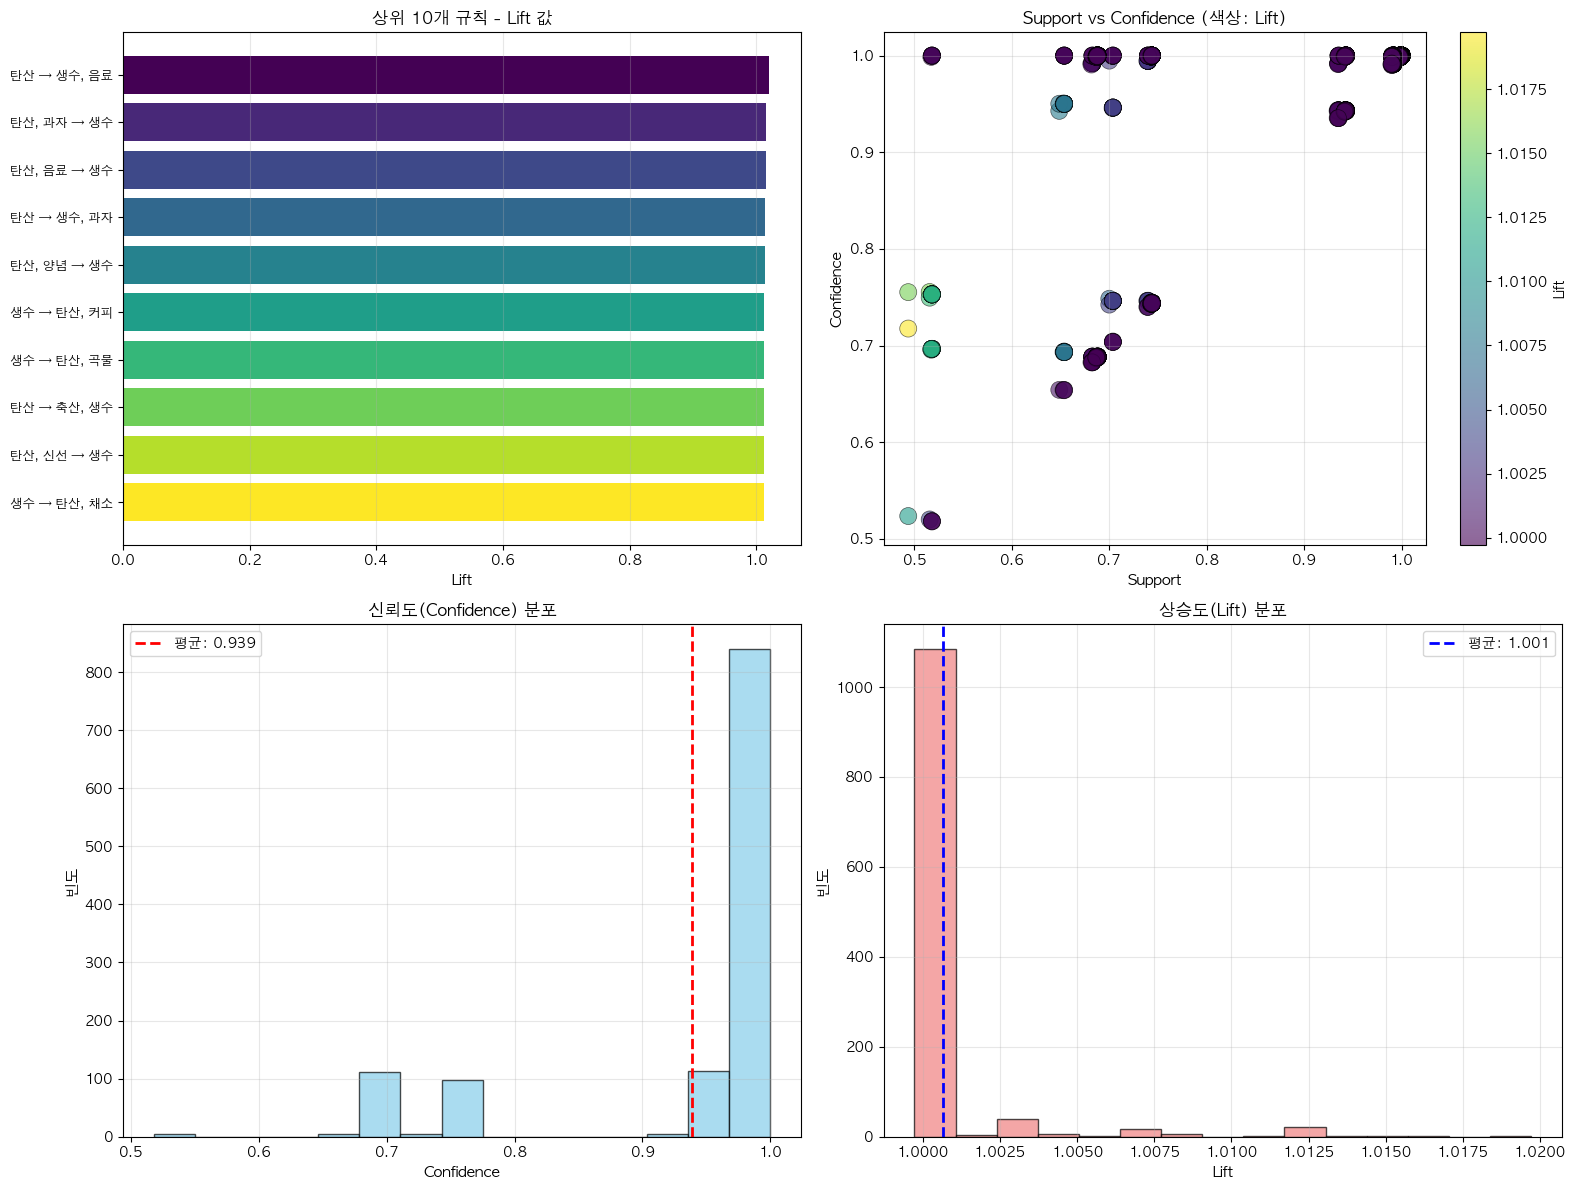


✓ 고객별 연관분석 시각화 저장: customer_association_analysis_middle.png


In [6]:
# 고객별 연관분석 시각화 (중분류)
if len(rules) > 5:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Lift 상위 10개 시각화
    top_rules = rules.head(10)
    ax = axes[0, 0]
    rules_labels = []
    for x, y in zip(top_rules['antecedents'], top_rules['consequents']):
        ant = ', '.join(list(x))
        cons = ', '.join(list(y))
        if len(ant) > 15:
            ant = ant[:15] + '...'
        if len(cons) > 15:
            cons = cons[:15] + '...'
        rules_labels.append(f"{ant} → {cons}")
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(top_rules)))
    ax.barh(range(len(top_rules)), top_rules['lift'].values, color=colors)
    ax.set_yticks(range(len(top_rules)))
    ax.set_yticklabels(rules_labels, fontsize=9)
    ax.set_xlabel('Lift', fontsize=11)
    ax.set_title('상위 10개 규칙 - Lift 값', fontsize=12, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(alpha=0.3, axis='x')
    
    # 2. Support vs Confidence 산점도
    ax = axes[0, 1]
    scatter = ax.scatter(rules['support'], rules['confidence'], 
                        c=rules['lift'], cmap='viridis', s=150, alpha=0.6, edgecolors='black', linewidth=0.5)
    ax.set_xlabel('Support', fontsize=11)
    ax.set_ylabel('Confidence', fontsize=11)
    ax.set_title('Support vs Confidence (색상: Lift)', fontsize=12, fontweight='bold')
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Lift', fontsize=10)
    ax.grid(alpha=0.3)
    
    # 3. Confidence 분포
    ax = axes[1, 0]
    ax.hist(rules['confidence'], bins=15, edgecolor='black', alpha=0.7, color='skyblue')
    ax.set_xlabel('Confidence', fontsize=11)
    ax.set_ylabel('빈도', fontsize=11)
    ax.set_title('신뢰도(Confidence) 분포', fontsize=12, fontweight='bold')
    ax.axvline(rules['confidence'].mean(), color='red', linestyle='--', linewidth=2, label=f'평균: {rules["confidence"].mean():.3f}')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # 4. Lift 분포
    ax = axes[1, 1]
    ax.hist(rules['lift'], bins=15, edgecolor='black', alpha=0.7, color='lightcoral')
    ax.set_xlabel('Lift', fontsize=11)
    ax.set_ylabel('빈도', fontsize=11)
    ax.set_title('상승도(Lift) 분포', fontsize=12, fontweight='bold')
    ax.axvline(rules['lift'].mean(), color='blue', linestyle='--', linewidth=2, label=f'평균: {rules["lift"].mean():.3f}')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('customer_association_analysis_middle.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ 고객별 연관분석 시각화 저장: customer_association_analysis_middle.png")
else:
    print("\n규칙이 충분하지 않아 시각화를 생성할 수 없습니다.")

In [7]:
# ============================================
# 2. 연령대별 연관분석 (중분류 기준)
# ============================================

age_groups = sorted(df['AgeGroup'].unique())
age_group_results = {}

print("\n" + "=" * 100)
print("【연령대별 연관분석 결과 (중분류 기준)】")
print("=" * 100)

for age_group in age_groups:
    # 해당 연령대 데이터 필터링
    age_df = df[df['AgeGroup'] == age_group]
    
    # 연령대별 구매 중분류 리스트
    age_products = age_df.groupby('idUser')['ItemMiddleName'].apply(list).reset_index()
    age_products.columns = ['idUser', 'products']
    
    # 거래 데이터 인코딩
    te_age = TransactionEncoder()
    te_age_ary = te_age.fit(age_products['products']).transform(age_products['products'])
    df_age_encoded = pd.DataFrame(te_age_ary, columns=te_age.columns_)
    
    # Apriori 알고리즘 (최소 지지도 5%, 최대 길이 3)
    frequent_itemsets_age = apriori(df_age_encoded, min_support=0.05, use_colnames=True, max_len=3)
    
    # 연관성 규칙 생성
    if len(frequent_itemsets_age) > 0:
        rules_age = association_rules(frequent_itemsets_age, metric="confidence", min_threshold=0.3)
        
        if len(rules_age) > 0:
            rules_age = rules_age.sort_values('lift', ascending=False)
            
            # 중복 제거 (같은 상품 쌍 중 Lift가 높은 방향 유지)
            rules_age_dedup = rules_age.copy()
            rules_age_dedup['상품A'] = rules_age_dedup['antecedents'].apply(lambda x: ', '.join(list(x)))
            rules_age_dedup['상품B'] = rules_age_dedup['consequents'].apply(lambda x: ', '.join(list(x)))
            rules_age_dedup['pair_key'] = rules_age_dedup.apply(
                lambda r: tuple(sorted([r['상품A'], r['상품B']])), axis=1
            )
            rules_age_dedup = rules_age_dedup.sort_values('lift', ascending=False).drop_duplicates(subset='pair_key', keep='first')
            
            age_group_results[age_group] = rules_age_dedup
            
            print(f"\n【{age_group}대】({len(age_df)} 건 거래, {age_df['idUser'].nunique()} 명 고객)")
            print(f"  전체 규칙: {len(rules_age)}개 → 중복 제거 후: {len(rules_age_dedup)}개 유니크 규칙")
            
            if len(rules_age_dedup) > 0:
                display_rules_age = rules_age_dedup[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5).copy()
                display_rules_age['상품A'] = display_rules_age['antecedents'].apply(lambda x: ', '.join(list(x)))
                display_rules_age['상품B'] = display_rules_age['consequents'].apply(lambda x: ', '.join(list(x)))
                result_age = display_rules_age[['상품A', '상품B', 'support', 'confidence', 'lift']].reset_index(drop=True)
                result_age.index = result_age.index + 1
                result_age.columns = ['중분류 A', '중분류 B', 'Support', 'Confidence', 'Lift']
                print(result_age.to_string())
        else:
            print(f"\n【{age_group}대】- 조건을 만족하는 규칙이 없습니다.")
    else:
        print(f"\n【{age_group}대】- 지지도가 0.05 이상인 항목집합이 없습니다.")


【연령대별 연관분석 결과 (중분류 기준)】

【20대】(233828 건 거래, 820 명 고객)
  전체 규칙: 2366개 → 중복 제거 후: 1183개 유니크 규칙
    중분류 A   중분류 B  Support  Confidence      Lift
1      탄산  생수, 음료  0.47439    0.732580  1.050202
2  탄산, 과자      생수  0.50000    0.773585  1.033126
3  탄산, 음료      생수  0.47439    0.773360  1.032826
4  생수, 수산      탄산  0.50000    0.667752  1.031181
5      생수  탄산, 곡물  0.50000    0.667752  1.031181

【30대】(362208 건 거래, 1280 명 고객)
  전체 규칙: 2366개 → 중복 제거 후: 1183개 유니크 규칙
    중분류 A   중분류 B   Support  Confidence      Lift
1  탄산, 음료      생수  0.495312    0.747642  1.019149
2      생수  탄산, 과자  0.517188    0.705005  1.015081
3      탄산  생수, 음료  0.495312    0.705228  1.014261
4      탄산  생수, 과자  0.517188    0.736374  1.011329
5      생수  탄산, 양념  0.520312    0.709265  1.010979

【40대】(137632 건 거래, 477 명 고객)
  전체 규칙: 2366개 → 중복 제거 후: 1183개 유니크 규칙
    중분류 A   중분류 B   Support  Confidence      Lift
1      커피  생수, 즉석  0.740042    0.741597  1.002101
2      커피  탄산, 생수  0.501048    0.502101  1.002101
3  생수, 채소      커피  0.74

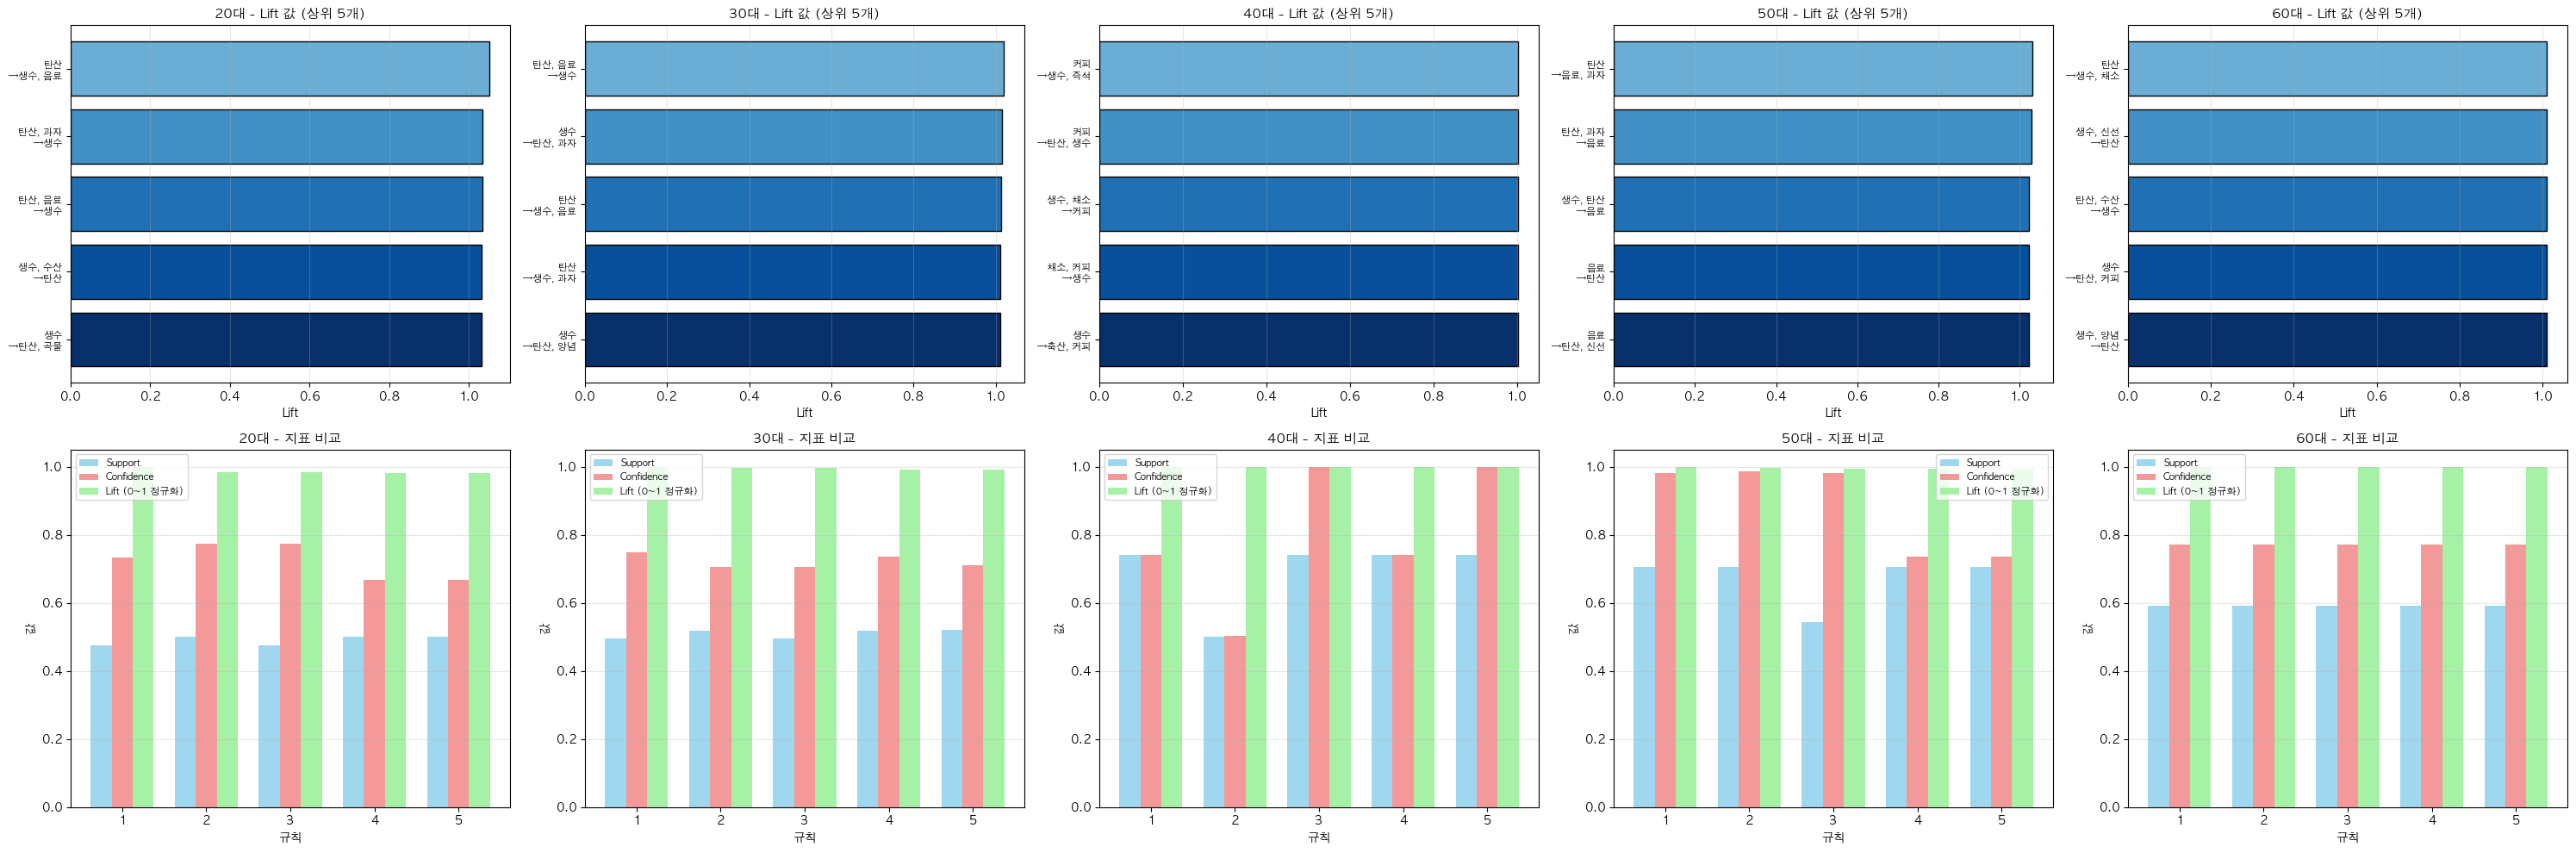


✓ 연령대별 연관분석 시각화 저장: age_group_association_analysis_middle.png


In [8]:
# 연령대별 연관분석 시각화 (중분류)
if age_group_results:
    num_age_groups = len(age_group_results)
    fig, axes = plt.subplots(2, num_age_groups, figsize=(6*num_age_groups, 10))
    
    if num_age_groups == 1:
        axes = axes.reshape(2, 1)
    
    for idx, (age_group, rules_age) in enumerate(age_group_results.items()):
        if len(rules_age) > 0:
            # 상위 5개 규칙
            top_rules_age = rules_age.head(5)
            
            # 1행: Lift 값 비교
            ax = axes[0, idx]
            rules_labels_age = []
            for x, y in zip(top_rules_age['antecedents'], top_rules_age['consequents']):
                ant = ', '.join(list(x))
                cons = ', '.join(list(y))
                if len(ant) > 12:
                    ant = ant[:12] + '...'
                if len(cons) > 12:
                    cons = cons[:12] + '...'
                rules_labels_age.append(f"{ant}\n→{cons}")
            
            colors = plt.cm.Blues(np.linspace(0.5, 1, len(top_rules_age)))
            ax.barh(range(len(top_rules_age)), top_rules_age['lift'].values, color=colors, edgecolor='black')
            ax.set_yticks(range(len(top_rules_age)))
            ax.set_yticklabels(rules_labels_age, fontsize=8)
            ax.set_xlabel('Lift')
            ax.set_title(f'{age_group}대 - Lift 값 (상위 5개)', fontsize=11, fontweight='bold')
            ax.invert_yaxis()
            ax.grid(alpha=0.3, axis='x')
            
            # 2행: 지표별 비교 (Support, Confidence, Lift)
            ax = axes[1, idx]
            x_pos = np.arange(len(top_rules_age))
            width = 0.25
            
            ax.bar(x_pos - width, top_rules_age['support'].values, width, label='Support', alpha=0.8, color='skyblue')
            ax.bar(x_pos, top_rules_age['confidence'].values, width, label='Confidence', alpha=0.8, color='lightcoral')
            ax.bar(x_pos + width, top_rules_age['lift'].values/max(rules_age['lift'].values), 
                   width, label='Lift (0~1 정규화)', alpha=0.8, color='lightgreen')
            
            ax.set_xlabel('규칙')
            ax.set_ylabel('값')
            ax.set_title(f'{age_group}대 - 지표 비교', fontsize=11, fontweight='bold')
            ax.set_xticks(x_pos)
            ax.set_xticklabels(range(1, len(top_rules_age)+1))
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('age_group_association_analysis_middle.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ 연령대별 연관분석 시각화 저장: age_group_association_analysis_middle.png")
else:
    print("\n연령대별 규칙을 찾을 수 없어 시각화를 생성할 수 없습니다.")


【연령대별 비교 분석 (중분류 기준)】

[연령대별 주요 지표]

연령대  고객수   거래건수  규칙수  평균Support  평균Confidence   평균Lift   최대Lift    평균구매중분류
20대  820 233828 1183   0.863946      0.933057 1.001121 1.050202 285.156098
30대 1280 362208 1183   0.871005      0.939445 1.000636 1.019149 282.975000
40대  477 137632 1183   0.870398      0.936237 0.999808 1.002101 288.536688
50대  291  83760 1183   0.886354      0.949188 1.001088 1.030435 287.835052
60대  132  36673 1183   0.892101      0.950687 1.000230 1.009313 277.825758


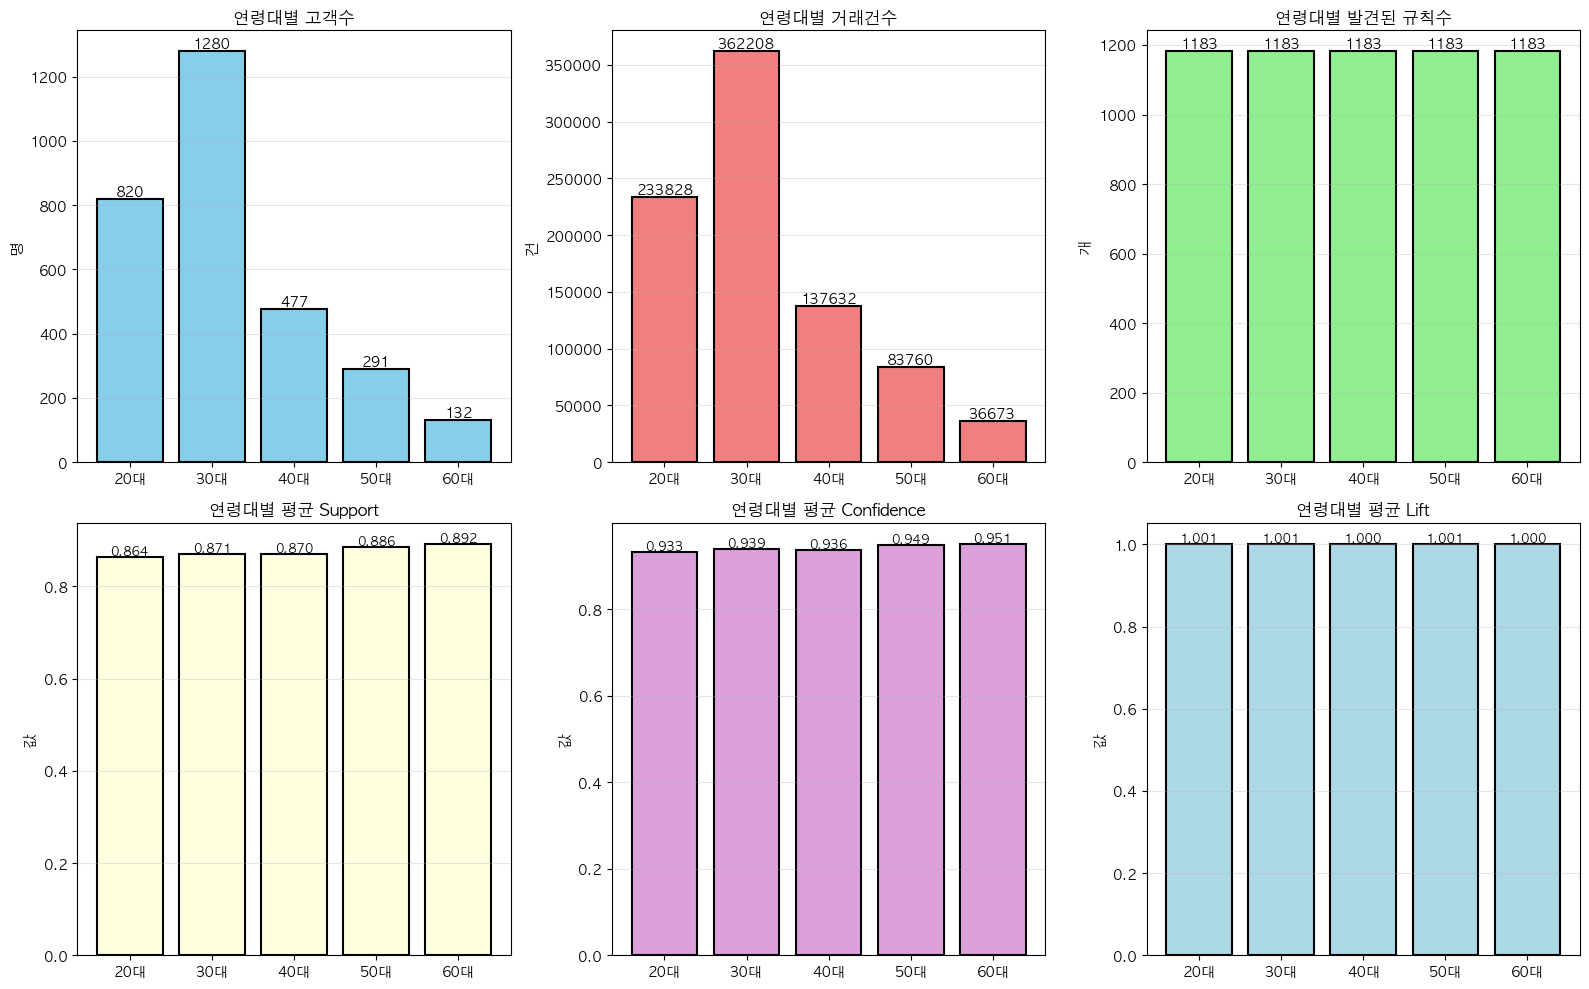


✓ 연령대별 비교 분석 시각화 저장: age_group_comparison_middle.png


In [9]:
# ============================================
# 3. 연령대별 비교 분석 (중분류 기준)
# ============================================

print("\n" + "=" * 100)
print("【연령대별 비교 분석 (중분류 기준)】")
print("=" * 100)

# 연령대별 주요 지표 비교
age_comparison = []

for age_group in age_groups:
    age_df = df[df['AgeGroup'] == age_group]
    
    if age_group in age_group_results:
        rules_age = age_group_results[age_group]
        
        age_comparison.append({
            '연령대': f'{age_group}대',
            '고객수': age_df['idUser'].nunique(),
            '거래건수': len(age_df),
            '규칙수': len(rules_age),
            '평균Support': rules_age['support'].mean(),
            '평균Confidence': rules_age['confidence'].mean(),
            '평균Lift': rules_age['lift'].mean(),
            '최대Lift': rules_age['lift'].max(),
            '평균구매중분류': age_df.groupby('idUser')['ItemMiddleName'].count().mean()
        })

comparison_df = pd.DataFrame(age_comparison)
print("\n[연령대별 주요 지표]\n")
print(comparison_df.to_string(index=False))

# 시각화: 연령대별 지표 비교
if len(comparison_df) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    # 1. 고객수
    ax = axes[0, 0]
    ax.bar(comparison_df['연령대'], comparison_df['고객수'], color='skyblue', edgecolor='black', linewidth=1.5)
    ax.set_ylabel('명', fontsize=11)
    ax.set_title('연령대별 고객수', fontweight='bold', fontsize=12)
    ax.grid(alpha=0.3, axis='y')
    for i, v in enumerate(comparison_df['고객수']):
        ax.text(i, v, str(int(v)), ha='center', va='bottom', fontweight='bold')
    
    # 2. 거래건수
    ax = axes[0, 1]
    ax.bar(comparison_df['연령대'], comparison_df['거래건수'], color='lightcoral', edgecolor='black', linewidth=1.5)
    ax.set_ylabel('건', fontsize=11)
    ax.set_title('연령대별 거래건수', fontweight='bold', fontsize=12)
    ax.grid(alpha=0.3, axis='y')
    for i, v in enumerate(comparison_df['거래건수']):
        ax.text(i, v, str(int(v)), ha='center', va='bottom', fontweight='bold')
    
    # 3. 발견된 규칙수
    ax = axes[0, 2]
    ax.bar(comparison_df['연령대'], comparison_df['규칙수'], color='lightgreen', edgecolor='black', linewidth=1.5)
    ax.set_ylabel('개', fontsize=11)
    ax.set_title('연령대별 발견된 규칙수', fontweight='bold', fontsize=12)
    ax.grid(alpha=0.3, axis='y')
    for i, v in enumerate(comparison_df['규칙수']):
        ax.text(i, v, str(int(v)), ha='center', va='bottom', fontweight='bold')
    
    # 4. 평균 Support
    ax = axes[1, 0]
    ax.bar(comparison_df['연령대'], comparison_df['평균Support'], color='lightyellow', edgecolor='black', linewidth=1.5)
    ax.set_ylabel('값', fontsize=11)
    ax.set_title('연령대별 평균 Support', fontweight='bold', fontsize=12)
    ax.grid(alpha=0.3, axis='y')
    for i, v in enumerate(comparison_df['평균Support']):
        ax.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    # 5. 평균 Confidence
    ax = axes[1, 1]
    ax.bar(comparison_df['연령대'], comparison_df['평균Confidence'], color='plum', edgecolor='black', linewidth=1.5)
    ax.set_ylabel('값', fontsize=11)
    ax.set_title('연령대별 평균 Confidence', fontweight='bold', fontsize=12)
    ax.grid(alpha=0.3, axis='y')
    for i, v in enumerate(comparison_df['평균Confidence']):
        ax.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    # 6. 평균 Lift
    ax = axes[1, 2]
    ax.bar(comparison_df['연령대'], comparison_df['평균Lift'], color='lightblue', edgecolor='black', linewidth=1.5)
    ax.set_ylabel('값', fontsize=11)
    ax.set_title('연령대별 평균 Lift', fontweight='bold', fontsize=12)
    ax.grid(alpha=0.3, axis='y')
    for i, v in enumerate(comparison_df['평균Lift']):
        ax.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('age_group_comparison_middle.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ 연령대별 비교 분석 시각화 저장: age_group_comparison_middle.png")

In [10]:
# ============================================
# 4. 주요 인사이트 및 요약 분석
# ============================================

print("\n" + "=" * 100)
print("【주요 인사이트 및 분석 요약 (중분류 기준)】")
print("=" * 100)

if len(rules) > 0:
    print("\n[전체 고객 연관분석 요약]")
    print(f"  ✓ 발견된 규칙 수(중복 제거): {len(rules)}개")
    print(f"  ✓ 평균 Support: {rules['support'].mean():.4f}")
    print(f"  ✓ 평균 Confidence: {rules['confidence'].mean():.4f}")
    print(f"  ✓ 평균 Lift: {rules['lift'].mean():.4f}")
    print(f"  ✓ 최고 Lift: {rules['lift'].max():.4f}")
    
    # 가장 강력한 규칙 찾기
    strongest_rule = rules.loc[rules['lift'].idxmax()]
    print(f"\n[가장 강력한 연관규칙]")
    ant_name = ', '.join(list(strongest_rule['antecedents']))
    cons_name = ', '.join(list(strongest_rule['consequents']))
    print(f"  ✓ 중분류 A: {ant_name}")
    print(f"  ✓ 중분류 B: {cons_name}")
    print(f"  ✓ 의미: {ant_name}을(를) 구매한 고객이 {cons_name}을(를) 구매할 확률")
    print(f"         {ant_name}을(를) 구매했을 때, 전체 고객 대비 {cons_name}을(를) 구매할 확률이 {(strongest_rule['lift']-1)*100:.1f}% 증가")
    print(f"  ✓ Confidence: {strongest_rule['confidence']:.1%}")
    print(f"  ✓ Support: {strongest_rule['support']:.4f}")
    
    # 가장 많이 등장하는 중분류 찾기
    from collections import Counter
    antecedents_list = []
    consequents_list = []
    
    for ant in rules['antecedents']:
        antecedents_list.extend(list(ant))
    for cons in rules['consequents']:
        consequents_list.extend(list(cons))
    
    ant_counter = Counter(antecedents_list)
    cons_counter = Counter(consequents_list)
    
    print(f"\n[가장 자주 선행 중분류로 나타나는 카테고리 TOP 5]")
    for rank, (product, count) in enumerate(ant_counter.most_common(5), 1):
        print(f"  {rank}. {product}: {count}회")
    
    print(f"\n[가장 자주 결과 중분류로 나타나는 카테고리 TOP 5]")
    for rank, (product, count) in enumerate(cons_counter.most_common(5), 1):
        print(f"  {rank}. {product}: {count}회")

# 연령대별 특징
if len(comparison_df) > 0:
    print(f"\n[연령대별 특징]")
    max_customer_idx = comparison_df['고객수'].idxmax()
    max_rules_idx = comparison_df['규칙수'].idxmax()
    max_lift_idx = comparison_df['평균Lift'].idxmax()
    max_conf_idx = comparison_df['평균Confidence'].idxmax()
    
    print(f"  ✓ 가장 많은 고객을 보유: {comparison_df.loc[max_customer_idx, '연령대']} ({int(comparison_df.loc[max_customer_idx, '고객수'])}명)")
    print(f"  ✓ 가장 많은 규칙 발견: {comparison_df.loc[max_rules_idx, '연령대']} ({int(comparison_df.loc[max_rules_idx, '규칙수'])}개)")
    print(f"  ✓ 평균 Lift 최고: {comparison_df.loc[max_lift_idx, '연령대']} ({comparison_df.loc[max_lift_idx, '평균Lift']:.4f})")
    print(f"  ✓ 평균 Confidence 최고: {comparison_df.loc[max_conf_idx, '연령대']} ({comparison_df.loc[max_conf_idx, '평균Confidence']:.4f})")

print("\n" + "=" * 100)
print("✅ 중분류 연관분석 완료!")
print("=" * 100)


【주요 인사이트 및 분석 요약 (중분류 기준)】

[전체 고객 연관분석 요약]
  ✓ 발견된 규칙 수(중복 제거): 1183개
  ✓ 평균 Support: 0.8714
  ✓ 평균 Confidence: 0.9387
  ✓ 평균 Lift: 1.0007
  ✓ 최고 Lift: 1.0197

[가장 강력한 연관규칙]
  ✓ 중분류 A: 탄산
  ✓ 중분류 B: 생수, 음료
  ✓ 의미: 탄산을(를) 구매한 고객이 생수, 음료을(를) 구매할 확률
         탄산을(를) 구매했을 때, 전체 고객 대비 생수, 음료을(를) 구매할 확률이 2.0% 증가
  ✓ Confidence: 71.8%
  ✓ Support: 0.4937

[가장 자주 선행 중분류로 나타나는 카테고리 TOP 5]
  1. 커피: 149회
  2. 양념: 143회
  3. 생수: 135회
  4. 탄산: 130회
  5. 과자: 130회

[가장 자주 결과 중분류로 나타나는 카테고리 TOP 5]
  1. 음료: 128회
  2. 냉동: 126회
  3. 과일: 125회
  4. 수산: 124회
  5. 채소: 121회

[연령대별 특징]
  ✓ 가장 많은 고객을 보유: 30대 (1280명)
  ✓ 가장 많은 규칙 발견: 20대 (1183개)
  ✓ 평균 Lift 최고: 20대 (1.0011)
  ✓ 평균 Confidence 최고: 60대 (0.9507)

✅ 중분류 연관분석 완료!


In [11]:
# ============================================
# 5. 연령대별 연관상품 TOP 10 (중복 제거 완료)
# ============================================

print("\n" + "=" * 120)
print("【연령대별 연관 중분류 TOP 10】(같은 중분류 쌍 중복 제거))")
print("=" * 120)

for age_group in age_groups:
    if age_group in age_group_results:
        rules_age = age_group_results[age_group]
        
        if len(rules_age) > 0:
            # TOP 10 추출 (이미 중복 제거된 상태)
            top_10 = rules_age.head(10).copy()
            top_10['상품A'] = top_10['antecedents'].apply(lambda x: ', '.join(list(x)))
            top_10['상품B'] = top_10['consequents'].apply(lambda x: ', '.join(list(x)))
            
            print(f"\n【{age_group}대】유니크 규칙 {len(rules_age)}개 중 상위 10개")
            print("-" * 120)
            
            result_table = top_10[['상품A', '상품B', 'support', 'confidence', 'lift']].reset_index(drop=True)
            result_table.index = result_table.index + 1
            result_table.columns = ['중분류 A', '중분류 B', 'Support', 'Confidence', 'Lift']
            
            # 각 지표를 읽기 쉽게 포맷
            for col in ['Support', 'Confidence', 'Lift']:
                if col == 'Support':
                    result_table[col] = result_table[col].apply(lambda x: f'{x:.4f}')
                elif col == 'Confidence':
                    result_table[col] = result_table[col].apply(lambda x: f'{x:.1%}')
                else:  # Lift
                    result_table[col] = result_table[col].apply(lambda x: f'{x:.4f}')
            
            print(result_table.to_string())
            print()
        else:
            print(f"\n【{age_group}대】규칙이 없습니다.\n")

print("=" * 120)


【연령대별 연관 중분류 TOP 10】(같은 중분류 쌍 중복 제거))

【20대】유니크 규칙 1183개 중 상위 10개
------------------------------------------------------------------------------------------------------------------------
     중분류 A   중분류 B Support Confidence    Lift
1       탄산  생수, 음료  0.4744      73.3%  1.0502
2   탄산, 과자      생수  0.5000      77.4%  1.0331
3   탄산, 음료      생수  0.4744      77.3%  1.0328
4   생수, 수산      탄산  0.5000      66.8%  1.0312
5       생수  탄산, 곡물  0.5000      66.8%  1.0312
6       탄산  생수, 곡물  0.5000      77.2%  1.0312
7       탄산  생수, 채소  0.5000      77.2%  1.0312
8       탄산  생수, 과자  0.5000      77.2%  1.0312
9   탄산, 채소      생수  0.5000      77.2%  1.0312
10  생수, 즉석      탄산  0.5000      66.8%  1.0312


【30대】유니크 규칙 1183개 중 상위 10개
------------------------------------------------------------------------------------------------------------------------
     중분류 A   중분류 B Support Confidence    Lift
1   탄산, 음료      생수  0.4953      74.8%  1.0191
2       생수  탄산, 과자  0.5172      70.5%  1.0151
3       탄산  생수, 음료

In [ ]:
# # ============================================
# # 6. 연관규칙 JSON 내보내기 (웹 시각화용)
# # ============================================
# import json, os

# os.makedirs('web/public/data', exist_ok=True)

# # 전체 고객단위 연관규칙 (lift 상위 500개)
# export_rules = []
# if len(rules) > 0:
#     top_rules = rules.nlargest(500, 'lift')
#     for _, row in top_rules.iterrows():
#         export_rules.append({
#             'antecedents': list(row['antecedents']),
#             'consequents': list(row['consequents']),
#             'support': round(row['support'], 4),
#             'confidence': round(row['confidence'], 4),
#             'lift': round(row['lift'], 4),
#             'ageGroup': '전체'
#         })

# # 연령대별 연관규칙
# age_rules_export = []
# for age_group, rules_age in age_group_results.items():
#     top_age = rules_age.nlargest(100, 'lift')
#     for _, row in top_age.iterrows():
#         age_rules_export.append({
#             'antecedents': list(row['antecedents']),
#             'consequents': list(row['consequents']),
#             'support': round(row['support'], 4),
#             'confidence': round(row['confidence'], 4),
#             'lift': round(row['lift'], 4),
#             'ageGroup': f'{age_group}대'
#         })

# all_rules = export_rules + age_rules_export

# with open('web/public/data/association_rules_middle.json', 'w', encoding='utf-8') as f:
#     json.dump(all_rules, f, ensure_ascii=False, indent=2)

# print(f"✓ 전체 규칙 {len(export_rules)}개 + 연령대별 {len(age_rules_export)}개 = 총 {len(all_rules)}개 내보내기 완료")
# print(f"  → web/public/data/association_rules_middle.json")

✓ 전체 규칙 500개 + 연령대별 500개 = 총 1000개 내보내기 완료
  → web/public/data/association_rules_middle.json


In [13]:
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.style as style
import numpy as np
import pandas as pd

import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway
import datetime
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')
print("라이브러리 로드 완료")


라이브러리 로드 완료


In [14]:
# 한글 폰트 설정
matplotlib.rc("font", family = "AppleGothic")
matplotlib.rc("axes", unicode_minus = False)

# 데이터 로드
df = pd.read_csv("df_merged.csv", encoding="cp949")
df = df.dropna()
print(f"데이터 shape: {df.shape}")
df.head()


데이터 shape: (854101, 34)


,idUser,idOrder,OrderDT,ItemCode,Price,DeliveryDT,OrderYear,OrderMonth,OrderDay,OrderHour,...,ItemSmallCode,ItemSmallName,ItemName,PriceMin,PriceMax,Gender,Age,FamilyCount,MemberYN,AgeGroup
0,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M17-S0530-1024,33310,2023-01-07 06:24:00,2023,1,6,17,...,S0530,전복,완도 활전복 1kg 중 22-25미,33160.0,37070.0,여성,26,2,Y,20
1,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M21-S0540-1082,3780,2023-01-07 06:24:00,2023,1,6,17,...,S0540,즉석,동원 양반 차돌된장찌개 (460G),3690.0,3970.0,여성,26,2,Y,20
2,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M15-S0140-1311,22520,2023-01-07 06:24:00,2023,1,6,17,...,S0140,냉동,오뚜기 듬뿍 새우볶음밥450g (2인분) x 5봉지 /,22150.0,23150.0,여성,26,2,Y,20
3,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M12-S0350-1035,21630,2023-01-07 06:24:00,2023,1,6,17,...,S0350,사과,[산지직송] 새콤달콤 부사 사과 5kg (13과내),20810.0,23030.0,여성,26,2,Y,20
4,U10001,U10001-O2023-1003,2023-01-13 16:50:14,L4-M12-S0640-1057,11700,2023-01-14 06:28:00,2023,1,13,16,...,S0640,토마토,스테비아 방울 토마토 라루 토망고 1kg,11640.0,13020.0,여성,26,2,Y,20


In [15]:
# 중분류 데이터 탐색
print(f"중분류 카테고리 수: {df['ItemMiddleName'].nunique()}")
print(f"소분류 카테고리 수: {df['ItemSmallName'].nunique()}")
print(f"\n→ 중분류는 소분류 대비 항목 수가 적어 연관규칙의 support가 높아지고, 더 안정적인 패턴 발견 가능\n")

# 중분류별 거래건수
middle_counts = df['ItemMiddleName'].value_counts()
print("=" * 60)
print("【중분류별 거래건수 (상위 20개)】")
print("=" * 60)
print(middle_counts.head(20).to_string())


중분류 카테고리 수: 14
소분류 카테고리 수: 58

→ 중분류는 소분류 대비 항목 수가 적어 연관규칙의 support가 높아지고, 더 안정적인 패턴 발견 가능

【중분류별 거래건수 (상위 20개)】
ItemMiddleName
과일    181625
채소    161894
수산    158760
곡물     71083
냉동     65633
축산     49448
양념     35594
신선     34781
즉석     32337
커피     28434
과자     17132
음료      9115
생수      4241
탄산      4024


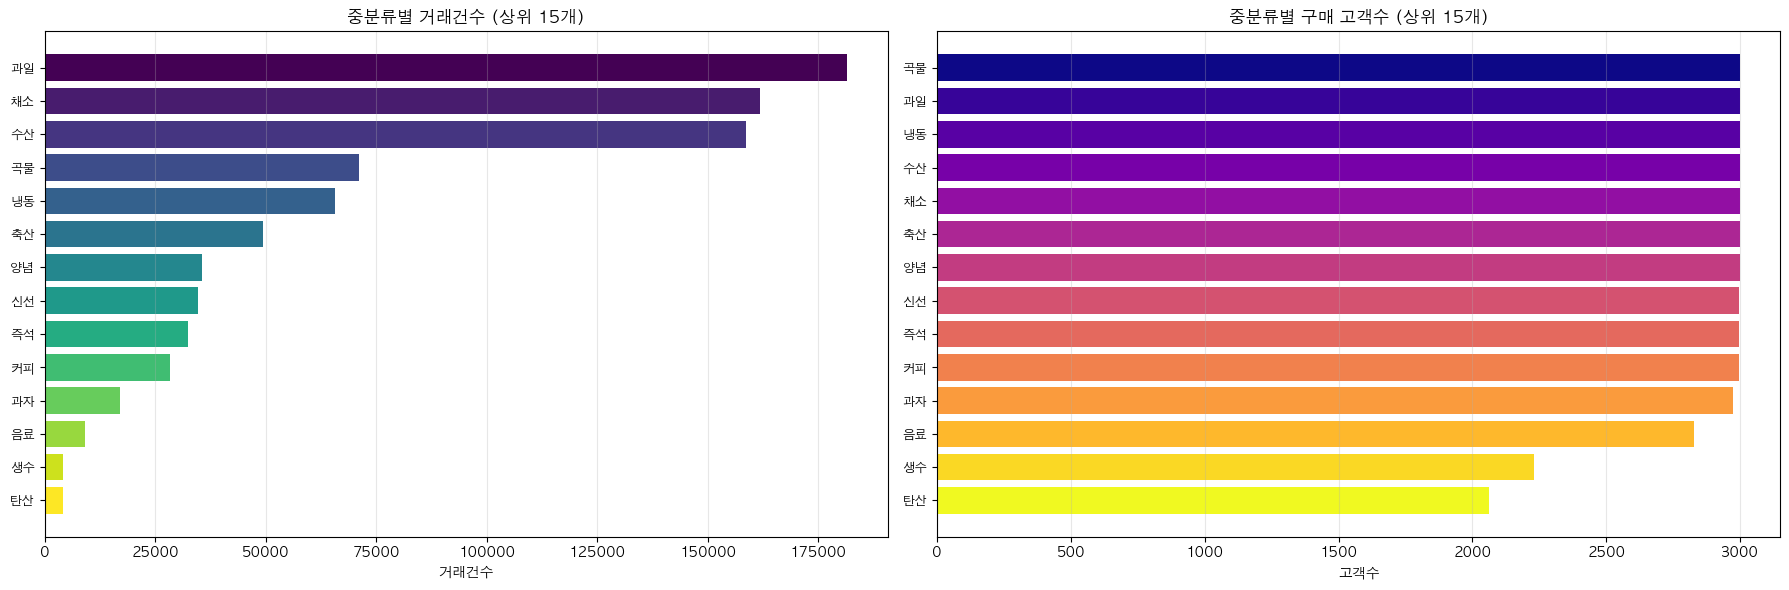

In [16]:
# 중분류 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 상위 15개 중분류 거래건수
ax = axes[0]
top15 = middle_counts.head(15)
ax.barh(range(len(top15)), top15.values, color=plt.cm.viridis(np.linspace(0, 1, len(top15))))
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15.index, fontsize=9)
ax.set_xlabel('거래건수')
ax.set_title('중분류별 거래건수 (상위 15개)', fontweight='bold')
ax.invert_yaxis()
ax.grid(alpha=0.3, axis='x')

# 중분류별 고객수
ax = axes[1]
middle_customers = df.groupby('ItemMiddleName')['idUser'].nunique().sort_values(ascending=False).head(15)
ax.barh(range(len(middle_customers)), middle_customers.values, color=plt.cm.plasma(np.linspace(0, 1, len(middle_customers))))
ax.set_yticks(range(len(middle_customers)))
ax.set_yticklabels(middle_customers.index, fontsize=9)
ax.set_xlabel('고객수')
ax.set_title('중분류별 구매 고객수 (상위 15개)', fontweight='bold')
ax.invert_yaxis()
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


In [17]:
# 1. 고객별 연관분석 (중분류 기준)
customer_products = df.groupby('idUser')['ItemMiddleName'].apply(list).reset_index()
customer_products.columns = ['idUser', 'products']

print(f"총 고객수: {len(customer_products)}")
print(f"평균 구매 중분류 수: {customer_products['products'].apply(len).mean():.2f}")

te = TransactionEncoder()
te_ary = te.fit(customer_products['products']).transform(customer_products['products'])
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"중분류 종류: {len(df_encoded.columns)}")
print(f"분석 시작...")

frequent_itemsets = apriori(df_encoded, min_support=0.03, use_colnames=True, max_len=3)
print(f"✓ 발견된 빈번한 항목집합: {len(frequent_itemsets)}개")

if len(frequent_itemsets) > 0:
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)
    
    if len(rules) > 0:
        rules = rules.sort_values('lift', ascending=False)
        
        rules_display = rules.copy()
        rules_display['상품A_temp'] = rules_display['antecedents'].apply(lambda x: ', '.join(list(x)))
        rules_display['상품B_temp'] = rules_display['consequents'].apply(lambda x: ', '.join(list(x)))
        rules_display['pair_key'] = rules_display.apply(
            lambda r: tuple(sorted([r['상품A_temp'], r['상품B_temp']])), axis=1
        )
        rules_display = rules_display.sort_values('lift', ascending=False).drop_duplicates(subset='pair_key', keep='first')
        rules = rules_display.drop(columns=['상품A_temp', '상품B_temp', 'pair_key'])
        
        print("=" * 100)
        print("【고객별 연관분석 결과 (중분류 기준)】")
        print("=" * 100)
        print(f"\n전체 규칙: {len(rules)}개 (중복 제거 완료)")
        print("\n[상위 15개 규칙 - Lift 순으로 정렬]\n")
        
        display_rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15).copy()
        display_rules['상품A'] = display_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
        display_rules['상품B'] = display_rules['consequents'].apply(lambda x: ', '.join(list(x)))
        result_df = display_rules[['상품A', '상품B', 'support', 'confidence', 'lift']].reset_index(drop=True)
        result_df.index = result_df.index + 1
        result_df.columns = ['중분류 A', '중분류 B', 'Support', 'Confidence', 'Lift']
        print(result_df.to_string())
    else:
        print("신뢰도가 0.3 이상인 규칙이 없습니다.")
        rules = pd.DataFrame()
else:
    print("지지도가 0.03 이상인 항목집합이 없습니다.")
    rules = pd.DataFrame()


총 고객수: 3000
평균 구매 중분류 수: 284.70
중분류 종류: 14
분석 시작...
✓ 발견된 빈번한 항목집합: 469개
【고객별 연관분석 결과 (중분류 기준)】

전체 규칙: 1183개 (중복 제거 완료)

[상위 15개 규칙 - Lift 순으로 정렬]

     중분류 A   중분류 B   Support  Confidence      Lift
1       탄산  생수, 음료  0.493667    0.717539  1.019714
2   탄산, 과자      생수  0.515667    0.755371  1.015739
3   탄산, 음료      생수  0.493667    0.755227  1.015545
4       탄산  생수, 과자  0.515667    0.749516  1.013315
5   탄산, 양념      생수  0.518000    0.753272  1.012916
6       생수  탄산, 커피  0.517333    0.695652  1.012594
7       생수  탄산, 곡물  0.518000    0.696549  1.012425
8       탄산  축산, 생수  0.518000    0.752907  1.012425
9   탄산, 신선      생수  0.518000    0.752907  1.012425
10      생수  탄산, 채소  0.518000    0.696549  1.012425
11  생수, 양념      탄산  0.518000    0.696549  1.012425
12      생수  탄산, 즉석  0.518000    0.696549  1.012425
13      탄산  생수, 곡물  0.518000    0.752907  1.012425
14  탄산, 냉동      생수  0.518000    0.752907  1.012425
15      탄산  생수, 냉동  0.518000    0.752907  1.012425


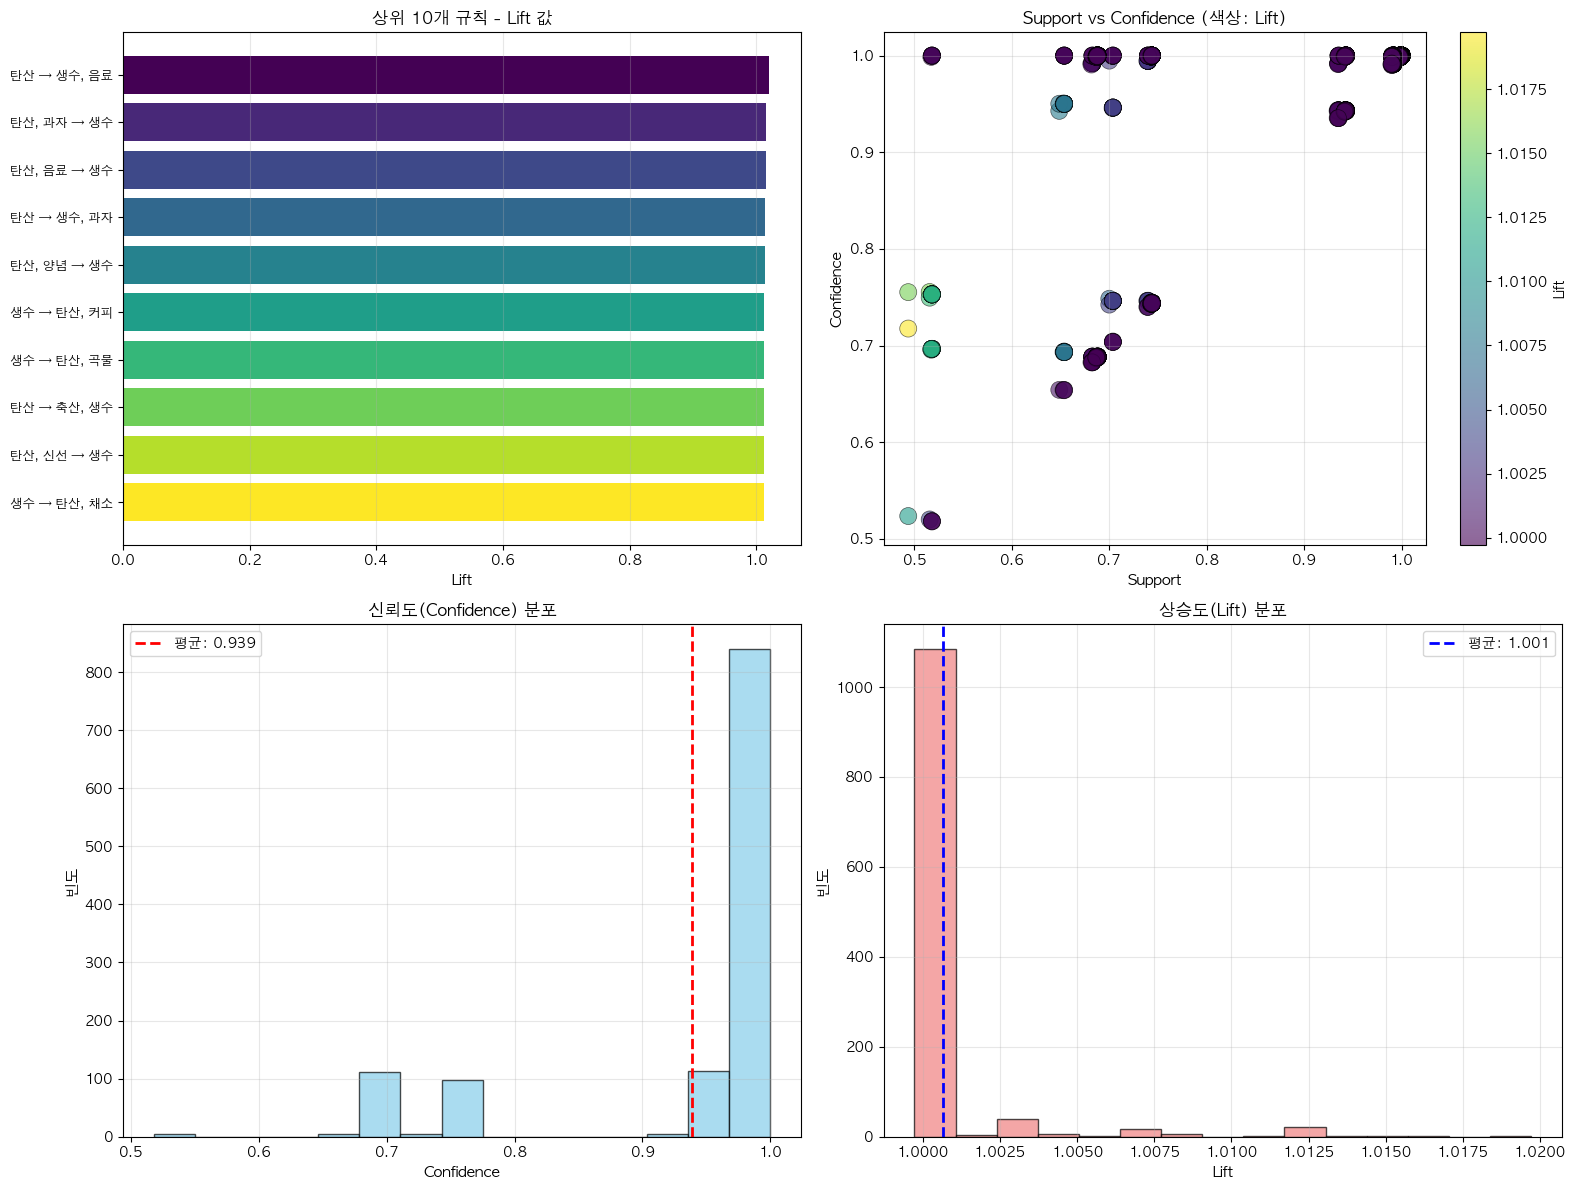


✓ 고객별 연관분석 시각화 저장: customer_association_analysis_middle.png


In [18]:
# 고객별 연관분석 시각화
if len(rules) > 5:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    top_rules = rules.head(10)
    ax = axes[0, 0]
    rules_labels = []
    for x, y in zip(top_rules['antecedents'], top_rules['consequents']):
        ant = ', '.join(list(x))
        cons = ', '.join(list(y))
        if len(ant) > 15:
            ant = ant[:15] + '...'
        if len(cons) > 15:
            cons = cons[:15] + '...'
        rules_labels.append(f"{ant} → {cons}")
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(top_rules)))
    ax.barh(range(len(top_rules)), top_rules['lift'].values, color=colors)
    ax.set_yticks(range(len(top_rules)))
    ax.set_yticklabels(rules_labels, fontsize=9)
    ax.set_xlabel('Lift', fontsize=11)
    ax.set_title('상위 10개 규칙 - Lift 값', fontsize=12, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(alpha=0.3, axis='x')
    
    ax = axes[0, 1]
    scatter = ax.scatter(rules['support'], rules['confidence'], 
                        c=rules['lift'], cmap='viridis', s=150, alpha=0.6, edgecolors='black', linewidth=0.5)
    ax.set_xlabel('Support', fontsize=11)
    ax.set_ylabel('Confidence', fontsize=11)
    ax.set_title('Support vs Confidence (색상: Lift)', fontsize=12, fontweight='bold')
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Lift', fontsize=10)
    ax.grid(alpha=0.3)
    
    ax = axes[1, 0]
    ax.hist(rules['confidence'], bins=15, edgecolor='black', alpha=0.7, color='skyblue')
    ax.set_xlabel('Confidence', fontsize=11)
    ax.set_ylabel('빈도', fontsize=11)
    ax.set_title('신뢰도(Confidence) 분포', fontsize=12, fontweight='bold')
    ax.axvline(rules['confidence'].mean(), color='red', linestyle='--', linewidth=2, label=f'평균: {rules["confidence"].mean():.3f}')
    ax.legend()
    ax.grid(alpha=0.3)
    
    ax = axes[1, 1]
    ax.hist(rules['lift'], bins=15, edgecolor='black', alpha=0.7, color='lightcoral')
    ax.set_xlabel('Lift', fontsize=11)
    ax.set_ylabel('빈도', fontsize=11)
    ax.set_title('상승도(Lift) 분포', fontsize=12, fontweight='bold')
    ax.axvline(rules['lift'].mean(), color='blue', linestyle='--', linewidth=2, label=f'평균: {rules["lift"].mean():.3f}')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('customer_association_analysis_middle.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\n✓ 고객별 연관분석 시각화 저장: customer_association_analysis_middle.png")


In [19]:
# 2. 연령대별 연관분석 (중분류 기준)
age_groups = sorted(df['AgeGroup'].unique())
age_group_results = {}

print("\n" + "=" * 100)
print("【연령대별 연관분석 결과 (중분류 기준)】")
print("=" * 100)

for age_group in age_groups:
    age_df = df[df['AgeGroup'] == age_group]
    
    age_products = age_df.groupby('idUser')['ItemMiddleName'].apply(list).reset_index()
    age_products.columns = ['idUser', 'products']
    
    te_age = TransactionEncoder()
    te_age_ary = te_age.fit(age_products['products']).transform(age_products['products'])
    df_age_encoded = pd.DataFrame(te_age_ary, columns=te_age.columns_)
    
    frequent_itemsets_age = apriori(df_age_encoded, min_support=0.05, use_colnames=True, max_len=3)
    
    if len(frequent_itemsets_age) > 0:
        rules_age = association_rules(frequent_itemsets_age, metric="confidence", min_threshold=0.3)
        
        if len(rules_age) > 0:
            rules_age = rules_age.sort_values('lift', ascending=False)
            
            rules_age_dedup = rules_age.copy()
            rules_age_dedup['상품A'] = rules_age_dedup['antecedents'].apply(lambda x: ', '.join(list(x)))
            rules_age_dedup['상품B'] = rules_age_dedup['consequents'].apply(lambda x: ', '.join(list(x)))
            rules_age_dedup['pair_key'] = rules_age_dedup.apply(
                lambda r: tuple(sorted([r['상품A'], r['상품B']])), axis=1
            )
            rules_age_dedup = rules_age_dedup.sort_values('lift', ascending=False).drop_duplicates(subset='pair_key', keep='first')
            
            age_group_results[age_group] = rules_age_dedup
            
            print(f"\n【{age_group}대】({len(age_df)} 건 거래, {age_df['idUser'].nunique()} 명 고객)")
            print(f"  전체 규칙: {len(rules_age)}개 → 중복 제거 후: {len(rules_age_dedup)}개 유니크 규칙")
            
            if len(rules_age_dedup) > 0:
                display_rules_age = rules_age_dedup[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5).copy()
                display_rules_age['상품A'] = display_rules_age['antecedents'].apply(lambda x: ', '.join(list(x)))
                display_rules_age['상품B'] = display_rules_age['consequents'].apply(lambda x: ', '.join(list(x)))
                result_age = display_rules_age[['상품A', '상품B', 'support', 'confidence', 'lift']].reset_index(drop=True)
                result_age.index = result_age.index + 1
                result_age.columns = ['중분류 A', '중분류 B', 'Support', 'Confidence', 'Lift']
                print(result_age.to_string())
        else:
            print(f"\n【{age_group}대】- 조건을 만족하는 규칙이 없습니다.")
    else:
        print(f"\n【{age_group}대】- 지지도가 0.05 이상인 항목집합이 없습니다.")



【연령대별 연관분석 결과 (중분류 기준)】

【20대】(233828 건 거래, 820 명 고객)
  전체 규칙: 2366개 → 중복 제거 후: 1183개 유니크 규칙
    중분류 A   중분류 B  Support  Confidence      Lift
1      탄산  생수, 음료  0.47439    0.732580  1.050202
2  탄산, 과자      생수  0.50000    0.773585  1.033126
3  탄산, 음료      생수  0.47439    0.773360  1.032826
4  생수, 수산      탄산  0.50000    0.667752  1.031181
5      생수  탄산, 곡물  0.50000    0.667752  1.031181

【30대】(362208 건 거래, 1280 명 고객)
  전체 규칙: 2366개 → 중복 제거 후: 1183개 유니크 규칙
    중분류 A   중분류 B   Support  Confidence      Lift
1  탄산, 음료      생수  0.495312    0.747642  1.019149
2      생수  탄산, 과자  0.517188    0.705005  1.015081
3      탄산  생수, 음료  0.495312    0.705228  1.014261
4      탄산  생수, 과자  0.517188    0.736374  1.011329
5      생수  탄산, 양념  0.520312    0.709265  1.010979

【40대】(137632 건 거래, 477 명 고객)
  전체 규칙: 2366개 → 중복 제거 후: 1183개 유니크 규칙
    중분류 A   중분류 B   Support  Confidence      Lift
1      커피  생수, 즉석  0.740042    0.741597  1.002101
2      커피  탄산, 생수  0.501048    0.502101  1.002101
3  생수, 채소      커피  0.74

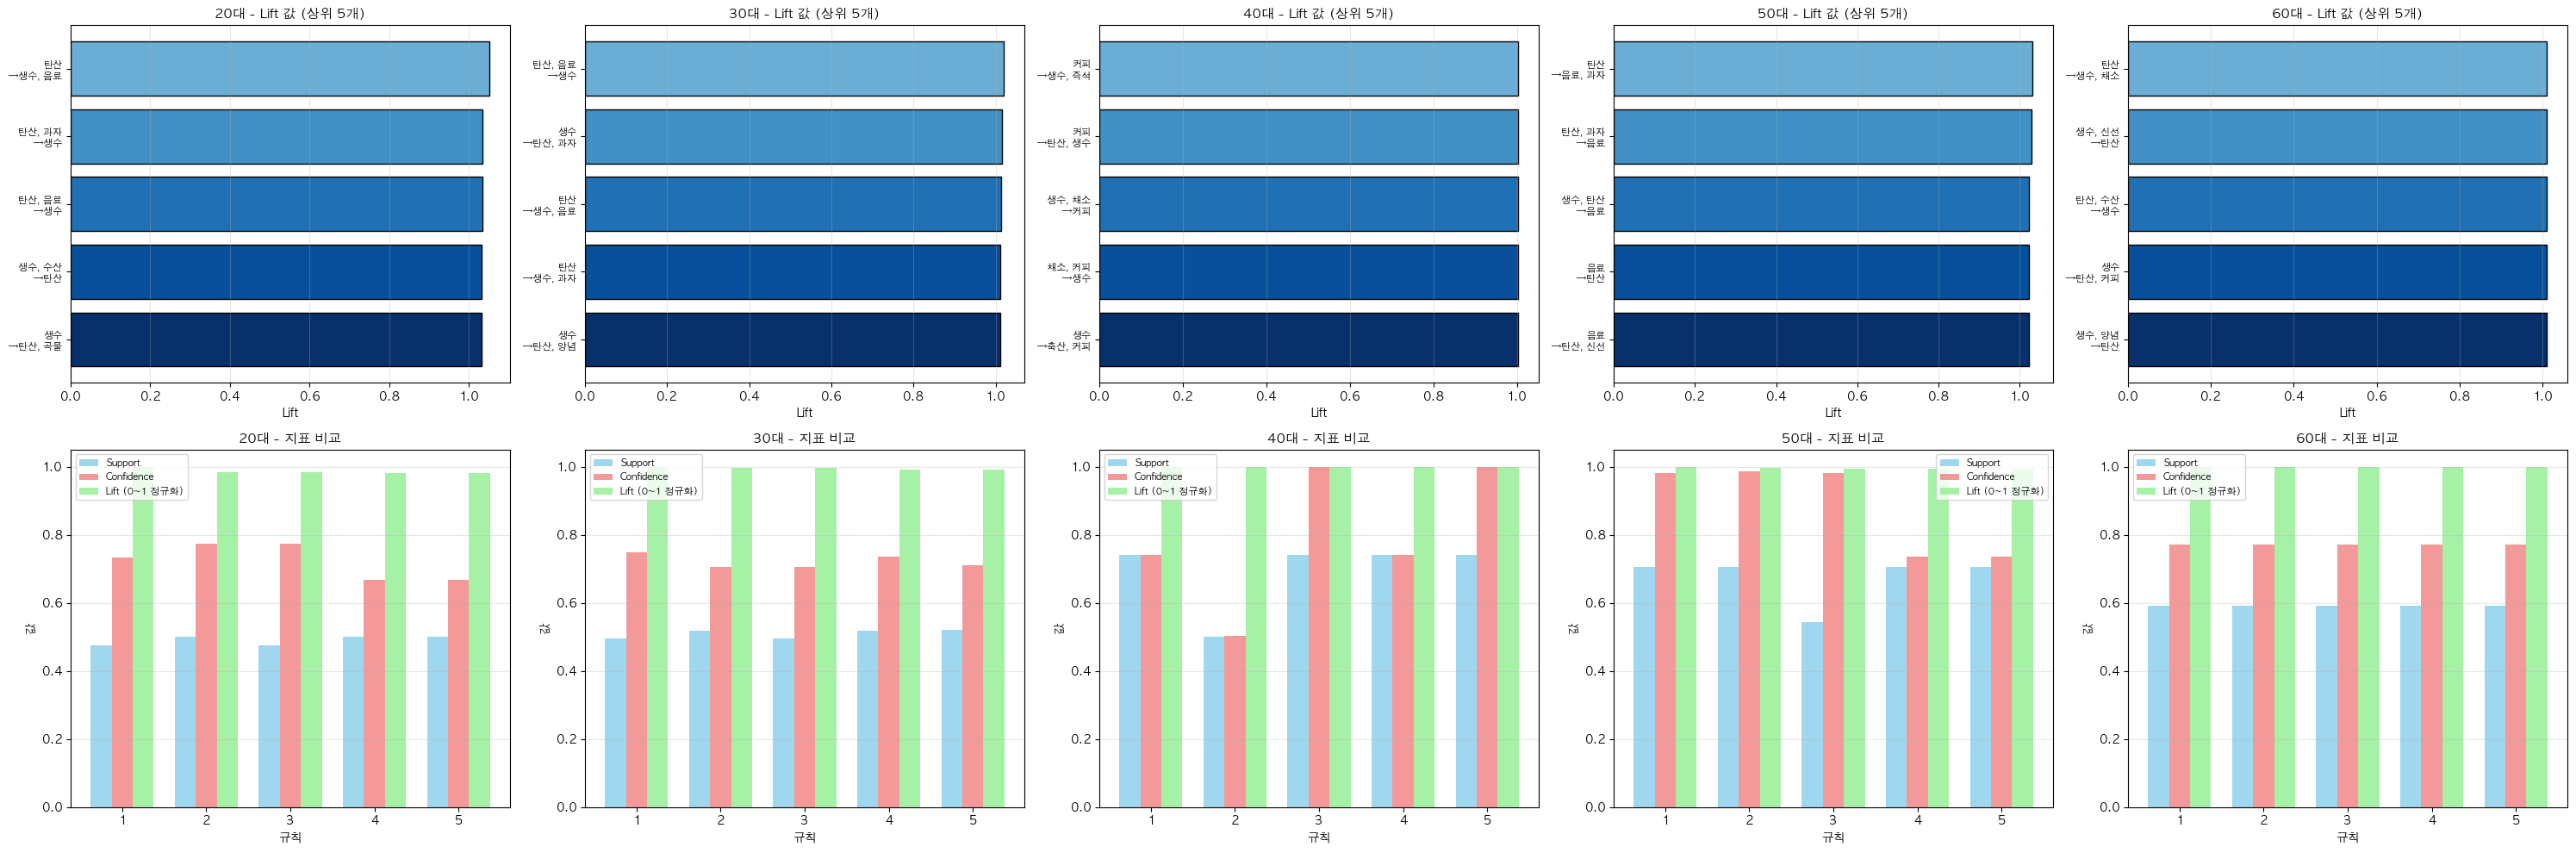


✓ 연령대별 연관분석 시각화 저장: age_group_association_analysis_middle.png


In [20]:
# 연령대별 연관분석 시각화
if age_group_results:
    num_age_groups = len(age_group_results)
    fig, axes = plt.subplots(2, num_age_groups, figsize=(6*num_age_groups, 10))
    
    if num_age_groups == 1:
        axes = axes.reshape(2, 1)
    
    for idx, (age_group, rules_age) in enumerate(age_group_results.items()):
        if len(rules_age) > 0:
            top_rules_age = rules_age.head(5)
            
            ax = axes[0, idx]
            rules_labels_age = []
            for x, y in zip(top_rules_age['antecedents'], top_rules_age['consequents']):
                ant = ', '.join(list(x))
                cons = ', '.join(list(y))
                if len(ant) > 12:
                    ant = ant[:12] + '...'
                if len(cons) > 12:
                    cons = cons[:12] + '...'
                rules_labels_age.append(f"{ant}\n→{cons}")
            
            colors = plt.cm.Blues(np.linspace(0.5, 1, len(top_rules_age)))
            ax.barh(range(len(top_rules_age)), top_rules_age['lift'].values, color=colors, edgecolor='black')
            ax.set_yticks(range(len(top_rules_age)))
            ax.set_yticklabels(rules_labels_age, fontsize=8)
            ax.set_xlabel('Lift')
            ax.set_title(f'{age_group}대 - Lift 값 (상위 5개)', fontsize=11, fontweight='bold')
            ax.invert_yaxis()
            ax.grid(alpha=0.3, axis='x')
            
            ax = axes[1, idx]
            x_pos = np.arange(len(top_rules_age))
            width = 0.25
            
            ax.bar(x_pos - width, top_rules_age['support'].values, width, label='Support', alpha=0.8, color='skyblue')
            ax.bar(x_pos, top_rules_age['confidence'].values, width, label='Confidence', alpha=0.8, color='lightcoral')
            ax.bar(x_pos + width, top_rules_age['lift'].values/max(rules_age['lift'].values), 
                   width, label='Lift (0~1 정규화)', alpha=0.8, color='lightgreen')
            
            ax.set_xlabel('규칙')
            ax.set_ylabel('값')
            ax.set_title(f'{age_group}대 - 지표 비교', fontsize=11, fontweight='bold')
            ax.set_xticks(x_pos)
            ax.set_xticklabels(range(1, len(top_rules_age)+1))
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('age_group_association_analysis_middle.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✓ 연령대별 연관분석 시각화 저장: age_group_association_analysis_middle.png")


In [21]:
# 3. 연령대별 비교 분석
print("\n" + "=" * 100)
print("【연령대별 비교 분석 (중분류 기준)】")
print("=" * 100)

age_comparison = []
for age_group in age_groups:
    age_df = df[df['AgeGroup'] == age_group]
    if age_group in age_group_results:
        rules_age = age_group_results[age_group]
        age_comparison.append({
            '연령대': f'{age_group}대',
            '고객수': age_df['idUser'].nunique(),
            '거래건수': len(age_df),
            '규칙수': len(rules_age),
            '평균Support': rules_age['support'].mean(),
            '평균Confidence': rules_age['confidence'].mean(),
            '평균Lift': rules_age['lift'].mean(),
            '최대Lift': rules_age['lift'].max(),
            '평균구매중분류': age_df.groupby('idUser')['ItemMiddleName'].count().mean()
        })

comparison_df = pd.DataFrame(age_comparison)
print("\n[연령대별 주요 지표]\n")
print(comparison_df.to_string(index=False))



【연령대별 비교 분석 (중분류 기준)】

[연령대별 주요 지표]

연령대  고객수   거래건수  규칙수  평균Support  평균Confidence   평균Lift   최대Lift    평균구매중분류
20대  820 233828 1183   0.863946      0.933057 1.001121 1.050202 285.156098
30대 1280 362208 1183   0.871005      0.939445 1.000636 1.019149 282.975000
40대  477 137632 1183   0.870398      0.936237 0.999808 1.002101 288.536688
50대  291  83760 1183   0.886354      0.949188 1.001088 1.030435 287.835052
60대  132  36673 1183   0.892101      0.950687 1.000230 1.009313 277.825758


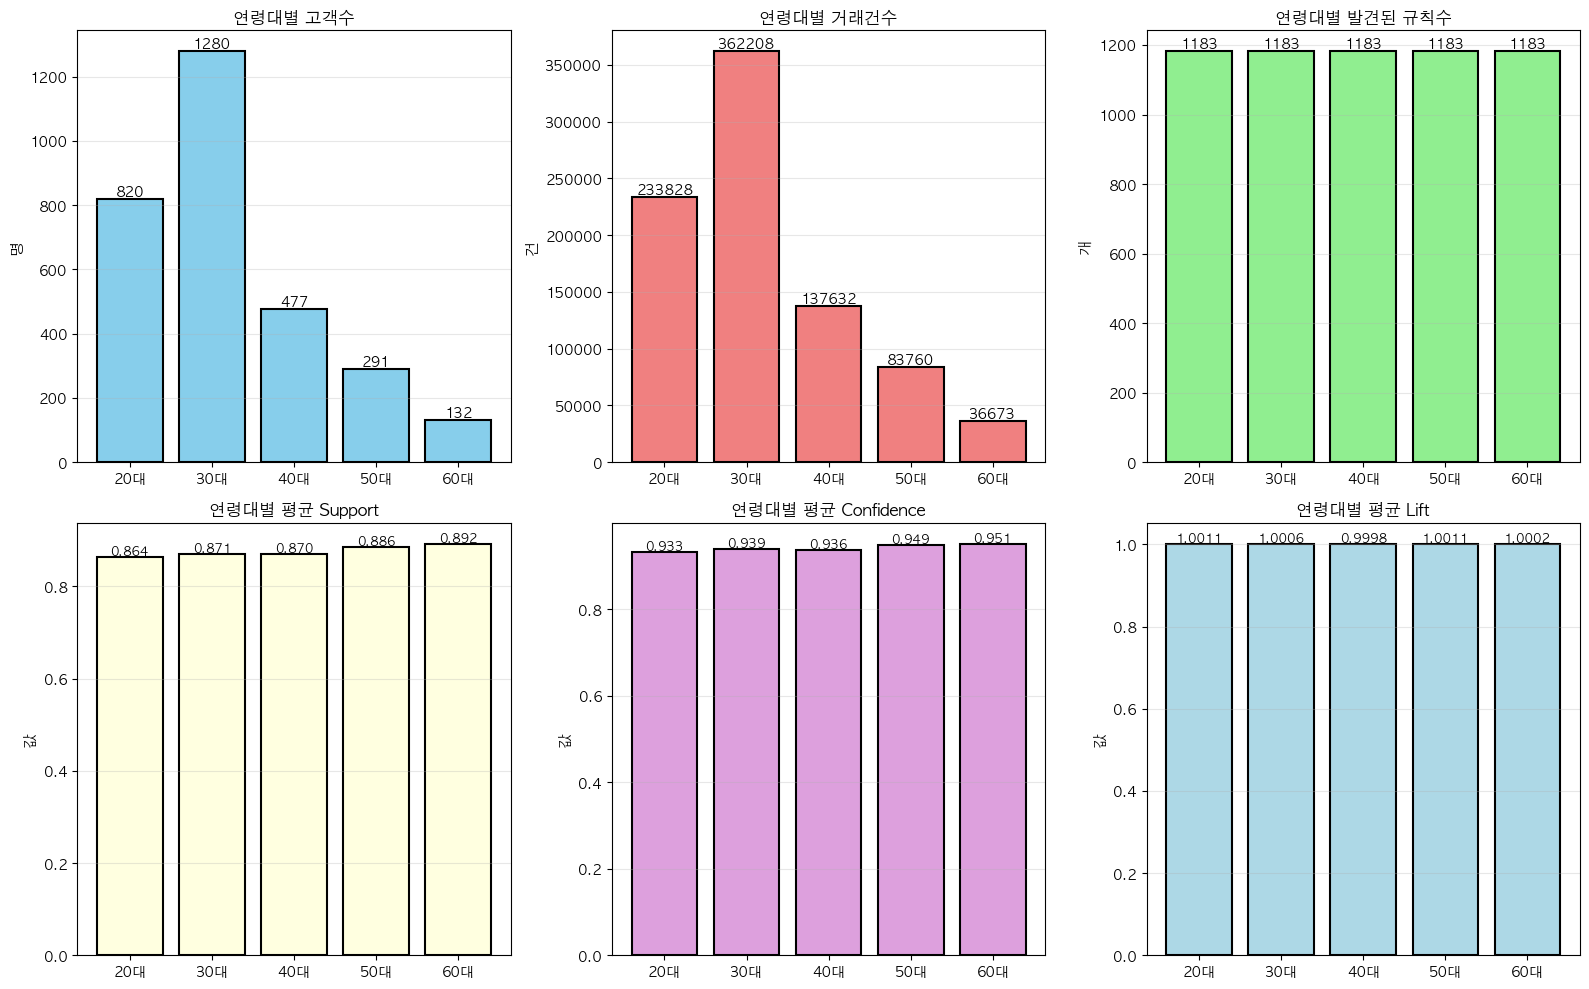


✓ 연령대별 비교 분석 시각화 저장: age_group_comparison_middle.png


In [22]:
# 연령대별 비교 시각화
if len(comparison_df) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    ax = axes[0, 0]
    ax.bar(comparison_df['연령대'], comparison_df['고객수'], color='skyblue', edgecolor='black', linewidth=1.5)
    ax.set_ylabel('명', fontsize=11)
    ax.set_title('연령대별 고객수', fontweight='bold', fontsize=12)
    ax.grid(alpha=0.3, axis='y')
    for i, v in enumerate(comparison_df['고객수']):
        ax.text(i, v, str(int(v)), ha='center', va='bottom', fontweight='bold')
    
    ax = axes[0, 1]
    ax.bar(comparison_df['연령대'], comparison_df['거래건수'], color='lightcoral', edgecolor='black', linewidth=1.5)
    ax.set_ylabel('건', fontsize=11)
    ax.set_title('연령대별 거래건수', fontweight='bold', fontsize=12)
    ax.grid(alpha=0.3, axis='y')
    for i, v in enumerate(comparison_df['거래건수']):
        ax.text(i, v, str(int(v)), ha='center', va='bottom', fontweight='bold')
    
    ax = axes[0, 2]
    ax.bar(comparison_df['연령대'], comparison_df['규칙수'], color='lightgreen', edgecolor='black', linewidth=1.5)
    ax.set_ylabel('개', fontsize=11)
    ax.set_title('연령대별 발견된 규칙수', fontweight='bold', fontsize=12)
    ax.grid(alpha=0.3, axis='y')
    for i, v in enumerate(comparison_df['규칙수']):
        ax.text(i, v, str(int(v)), ha='center', va='bottom', fontweight='bold')
    
    ax = axes[1, 0]
    ax.bar(comparison_df['연령대'], comparison_df['평균Support'], color='lightyellow', edgecolor='black', linewidth=1.5)
    ax.set_ylabel('값', fontsize=11)
    ax.set_title('연령대별 평균 Support', fontweight='bold', fontsize=12)
    ax.grid(alpha=0.3, axis='y')
    for i, v in enumerate(comparison_df['평균Support']):
        ax.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    ax = axes[1, 1]
    ax.bar(comparison_df['연령대'], comparison_df['평균Confidence'], color='plum', edgecolor='black', linewidth=1.5)
    ax.set_ylabel('값', fontsize=11)
    ax.set_title('연령대별 평균 Confidence', fontweight='bold', fontsize=12)
    ax.grid(alpha=0.3, axis='y')
    for i, v in enumerate(comparison_df['평균Confidence']):
        ax.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    ax = axes[1, 2]
    ax.bar(comparison_df['연령대'], comparison_df['평균Lift'], color='lightblue', edgecolor='black', linewidth=1.5)
    ax.set_ylabel('값', fontsize=11)
    ax.set_title('연령대별 평균 Lift', fontweight='bold', fontsize=12)
    ax.grid(alpha=0.3, axis='y')
    for i, v in enumerate(comparison_df['평균Lift']):
        ax.text(i, v, f'{v:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('age_group_comparison_middle.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✓ 연령대별 비교 분석 시각화 저장: age_group_comparison_middle.png")


In [23]:
# 4. 주요 인사이트 및 요약
print("\n" + "=" * 100)
print("【주요 인사이트 및 분석 요약 (중분류 기준)】")
print("=" * 100)

if len(rules) > 0:
    print("\n[전체 고객 연관분석 요약]")
    print(f"  ✓ 발견된 규칙 수(중복 제거): {len(rules)}개")
    print(f"  ✓ 평균 Support: {rules['support'].mean():.4f}")
    print(f"  ✓ 평균 Confidence: {rules['confidence'].mean():.4f}")
    print(f"  ✓ 평균 Lift: {rules['lift'].mean():.4f}")
    print(f"  ✓ 최고 Lift: {rules['lift'].max():.4f}")
    
    strongest_rule = rules.loc[rules['lift'].idxmax()]
    print(f"\n[가장 강력한 연관규칙]")
    ant_name = ', '.join(list(strongest_rule['antecedents']))
    cons_name = ', '.join(list(strongest_rule['consequents']))
    print(f"  ✓ 중분류 A: {ant_name}")
    print(f"  ✓ 중분류 B: {cons_name}")
    print(f"  ✓ Confidence: {strongest_rule['confidence']:.1%}")
    print(f"  ✓ Support: {strongest_rule['support']:.4f}")
    print(f"  ✓ Lift: {strongest_rule['lift']:.4f}")
    
    from collections import Counter
    antecedents_list = []
    consequents_list = []
    for ant in rules['antecedents']:
        antecedents_list.extend(list(ant))
    for cons in rules['consequents']:
        consequents_list.extend(list(cons))
    
    ant_counter = Counter(antecedents_list)
    cons_counter = Counter(consequents_list)
    
    print(f"\n[가장 자주 선행 중분류로 나타나는 카테고리 TOP 5]")
    for rank, (product, count) in enumerate(ant_counter.most_common(5), 1):
        print(f"  {rank}. {product}: {count}회")
    
    print(f"\n[가장 자주 결과 중분류로 나타나는 카테고리 TOP 5]")
    for rank, (product, count) in enumerate(cons_counter.most_common(5), 1):
        print(f"  {rank}. {product}: {count}회")

if len(comparison_df) > 0:
    print(f"\n[연령대별 특징]")
    max_customer_idx = comparison_df['고객수'].idxmax()
    max_lift_idx = comparison_df['최대Lift'].idxmax()
    max_conf_idx = comparison_df['평균Confidence'].idxmax()
    
    print(f"  ✓ 가장 많은 고객을 보유: {comparison_df.loc[max_customer_idx, '연령대']} ({int(comparison_df.loc[max_customer_idx, '고객수'])}명)")
    print(f"  ✓ 최대 Lift 최고: {comparison_df.loc[max_lift_idx, '연령대']} ({comparison_df.loc[max_lift_idx, '최대Lift']:.4f})")
    print(f"  ✓ 평균 Confidence 최고: {comparison_df.loc[max_conf_idx, '연령대']} ({comparison_df.loc[max_conf_idx, '평균Confidence']:.4f})")



【주요 인사이트 및 분석 요약 (중분류 기준)】

[전체 고객 연관분석 요약]
  ✓ 발견된 규칙 수(중복 제거): 1183개
  ✓ 평균 Support: 0.8714
  ✓ 평균 Confidence: 0.9387
  ✓ 평균 Lift: 1.0007
  ✓ 최고 Lift: 1.0197

[가장 강력한 연관규칙]
  ✓ 중분류 A: 탄산
  ✓ 중분류 B: 생수, 음료
  ✓ Confidence: 71.8%
  ✓ Support: 0.4937
  ✓ Lift: 1.0197

[가장 자주 선행 중분류로 나타나는 카테고리 TOP 5]
  1. 커피: 149회
  2. 양념: 143회
  3. 생수: 135회
  4. 탄산: 130회
  5. 과자: 130회

[가장 자주 결과 중분류로 나타나는 카테고리 TOP 5]
  1. 음료: 128회
  2. 냉동: 126회
  3. 과일: 125회
  4. 수산: 124회
  5. 채소: 121회

[연령대별 특징]
  ✓ 가장 많은 고객을 보유: 30대 (1280명)
  ✓ 최대 Lift 최고: 20대 (1.0502)
  ✓ 평균 Confidence 최고: 60대 (0.9507)


In [24]:
# 5. 연령대별 연관상품 TOP 10
print("\n" + "=" * 120)
print("【연령대별 연관 중분류 TOP 10】(같은 중분류 쌍 중복 제거)")
print("=" * 120)

for age_group in age_groups:
    if age_group in age_group_results:
        rules_age = age_group_results[age_group]
        
        if len(rules_age) > 0:
            top_10 = rules_age.head(10).copy()
            top_10['상품A'] = top_10['antecedents'].apply(lambda x: ', '.join(list(x)))
            top_10['상품B'] = top_10['consequents'].apply(lambda x: ', '.join(list(x)))
            
            print(f"\n【{age_group}대】유니크 규칙 {len(rules_age)}개 중 상위 10개")
            print("-" * 120)
            
            result_table = top_10[['상품A', '상품B', 'support', 'confidence', 'lift']].reset_index(drop=True)
            result_table.index = result_table.index + 1
            result_table.columns = ['중분류 A', '중분류 B', 'Support', 'Confidence', 'Lift']
            
            for col in ['Support', 'Confidence', 'Lift']:
                if col == 'Support':
                    result_table[col] = result_table[col].apply(lambda x: f'{x:.4f}')
                elif col == 'Confidence':
                    result_table[col] = result_table[col].apply(lambda x: f'{x:.1%}')
                else:
                    result_table[col] = result_table[col].apply(lambda x: f'{x:.4f}')
            
            print(result_table.to_string())
            print()

print("=" * 120)



【연령대별 연관 중분류 TOP 10】(같은 중분류 쌍 중복 제거)

【20대】유니크 규칙 1183개 중 상위 10개
------------------------------------------------------------------------------------------------------------------------
     중분류 A   중분류 B Support Confidence    Lift
1       탄산  생수, 음료  0.4744      73.3%  1.0502
2   탄산, 과자      생수  0.5000      77.4%  1.0331
3   탄산, 음료      생수  0.4744      77.3%  1.0328
4   생수, 수산      탄산  0.5000      66.8%  1.0312
5       생수  탄산, 곡물  0.5000      66.8%  1.0312
6       탄산  생수, 곡물  0.5000      77.2%  1.0312
7       탄산  생수, 채소  0.5000      77.2%  1.0312
8       탄산  생수, 과자  0.5000      77.2%  1.0312
9   탄산, 채소      생수  0.5000      77.2%  1.0312
10  생수, 즉석      탄산  0.5000      66.8%  1.0312


【30대】유니크 규칙 1183개 중 상위 10개
------------------------------------------------------------------------------------------------------------------------
     중분류 A   중분류 B Support Confidence    Lift
1   탄산, 음료      생수  0.4953      74.8%  1.0191
2       생수  탄산, 과자  0.5172      70.5%  1.0151
3       탄산  생수, 음료 

# 소분류 드릴다운 연관분석
중분류 연관분석에서 발견된 패턴을 기반으로, 연령대별 소분류(ItemSmallName) 수준의 구체적인 연관상품을 도출

In [25]:
# 6. 연령대별 소분류 연관분석 (드릴다운)
age_groups = sorted(df['AgeGroup'].unique())
age_small_results = {}

print("=" * 120)
print("【연령대별 소분류 연관분석 (드릴다운)】")
print("=" * 120)

for age_group in age_groups:
    age_df = df[df['AgeGroup'] == age_group]
    
    age_products = age_df.groupby('idUser')['ItemSmallName'].apply(list).reset_index()
    age_products.columns = ['idUser', 'products']
    
    te_age = TransactionEncoder()
    te_age_ary = te_age.fit(age_products['products']).transform(age_products['products'])
    df_age_encoded = pd.DataFrame(te_age_ary, columns=te_age.columns_)
    
    print(f"\n【{age_group}대】고객수: {len(age_products)}, 소분류 종류: {len(df_age_encoded.columns)}")
    
    frequent_itemsets_age = apriori(df_age_encoded, min_support=0.05, use_colnames=True, max_len=2)
    
    if len(frequent_itemsets_age) > 0:
        rules_age = association_rules(frequent_itemsets_age, metric="confidence", min_threshold=0.3)
        
        if len(rules_age) > 0:
            rules_age = rules_age.sort_values('lift', ascending=False)
            
            rules_age_dedup = rules_age.copy()
            rules_age_dedup['A'] = rules_age_dedup['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
            rules_age_dedup['B'] = rules_age_dedup['consequents'].apply(lambda x: ', '.join(sorted(list(x))))
            rules_age_dedup['pair_key'] = rules_age_dedup.apply(
                lambda r: tuple(sorted([r['A'], r['B']])), axis=1
            )
            rules_age_dedup = rules_age_dedup.drop_duplicates(subset='pair_key', keep='first')
            rules_age_dedup = rules_age_dedup.drop(columns=['A', 'B', 'pair_key'])
            
            age_small_results[age_group] = rules_age_dedup
            
            print(f"  빈번한 항목집합: {len(frequent_itemsets_age)}개, 규칙(중복제거): {len(rules_age_dedup)}개")
        else:
            print(f"  규칙 없음 (confidence 0.3 이상)")
    else:
        print(f"  빈번한 항목집합 없음 (support 0.05 이상)")


【연령대별 소분류 연관분석 (드릴다운)】

【20대】고객수: 820, 소분류 종류: 58
  빈번한 항목집합: 1711개, 규칙(중복제거): 1653개

【30대】고객수: 1280, 소분류 종류: 58
  빈번한 항목집합: 1711개, 규칙(중복제거): 1653개

【40대】고객수: 477, 소분류 종류: 58
  빈번한 항목집합: 1711개, 규칙(중복제거): 1653개

【50대】고객수: 291, 소분류 종류: 58
  빈번한 항목집합: 1711개, 규칙(중복제거): 1653개

【60대】고객수: 132, 소분류 종류: 58
  빈번한 항목집합: 1711개, 규칙(중복제거): 1653개


In [26]:
# 7. 연령대별 소분류 연관상품 TOP 15
print("=" * 120)
print("【연령대별 소분류 연관상품 TOP 15】(Lift 기준 정렬)")
print("=" * 120)

small_to_middle = df.drop_duplicates(subset='ItemSmallName')[['ItemSmallName', 'ItemMiddleName']].set_index('ItemSmallName')['ItemMiddleName'].to_dict()

for age_group in age_groups:
    if age_group in age_small_results:
        rules_age = age_small_results[age_group]
        
        if len(rules_age) > 0:
            top_n = rules_age.head(15).copy()
            top_n['소분류A'] = top_n['antecedents'].apply(lambda x: ', '.join(list(x)))
            top_n['소분류B'] = top_n['consequents'].apply(lambda x: ', '.join(list(x)))
            top_n['중분류A'] = top_n['antecedents'].apply(lambda x: ', '.join([small_to_middle.get(i, '?') for i in list(x)]))
            top_n['중분류B'] = top_n['consequents'].apply(lambda x: ', '.join([small_to_middle.get(i, '?') for i in list(x)]))
            
            print(f"\n【{age_group}대】규칙 {len(rules_age)}개 중 상위 15개")
            print("-" * 120)
            
            result_table = top_n[['소분류A', '중분류A', '소분류B', '중분류B', 'support', 'confidence', 'lift']].reset_index(drop=True)
            result_table.index = result_table.index + 1
            result_table.columns = ['소분류 A', '(중분류)', '소분류 B', '(중분류)', 'Support', 'Confidence', 'Lift']
            
            result_table['Support'] = result_table['Support'].apply(lambda x: f'{x:.4f}')
            result_table['Confidence'] = result_table['Confidence'].apply(lambda x: f'{x:.1%}')
            result_table['Lift'] = result_table['Lift'].apply(lambda x: f'{x:.4f}')
            
            print(result_table.to_string())
            print()

print("=" * 120)


【연령대별 소분류 연관상품 TOP 15】(Lift 기준 정렬)

【20대】규칙 1653개 중 상위 15개
------------------------------------------------------------------------------------------------------------------------
   소분류 A (중분류) 소분류 B (중분류) Support Confidence    Lift
1     갈치    수산    참외    과일  0.2976      49.7%  1.1013
2    콩나물    채소    참외    과일  0.1268      49.3%  1.0924
3    콩나물    채소  탄산음료    탄산  0.1780      69.2%  1.0685
4    콩나물    채소    갈치    수산  0.1646      64.0%  1.0685
5     깻잎    채소  탄산음료    탄산  0.4098      69.0%  1.0654
6    콩나물    채소   아몬드    곡물  0.2268      88.2%  1.0568
7    콩나물    채소    땅콩    곡물  0.2049      79.6%  1.0565
8     깻잎    채소   파스타    곡물  0.4646      78.2%  1.0517
9     갈치    수산    깻잎    채소  0.3732      62.3%  1.0494
10    참외    과일    북어    수산  0.3671      81.4%  1.0472
11    참외    과일    깻잎    채소  0.2805      62.2%  1.0467
12   콩나물    채소    깻잎    채소  0.1598      62.1%  1.0454
13   콩나물    채소   파스타    곡물  0.2000      77.7%  1.0448
14    깻잎    채소    북어    수산  0.4817      81.1%  1.0441
15   콩나물  

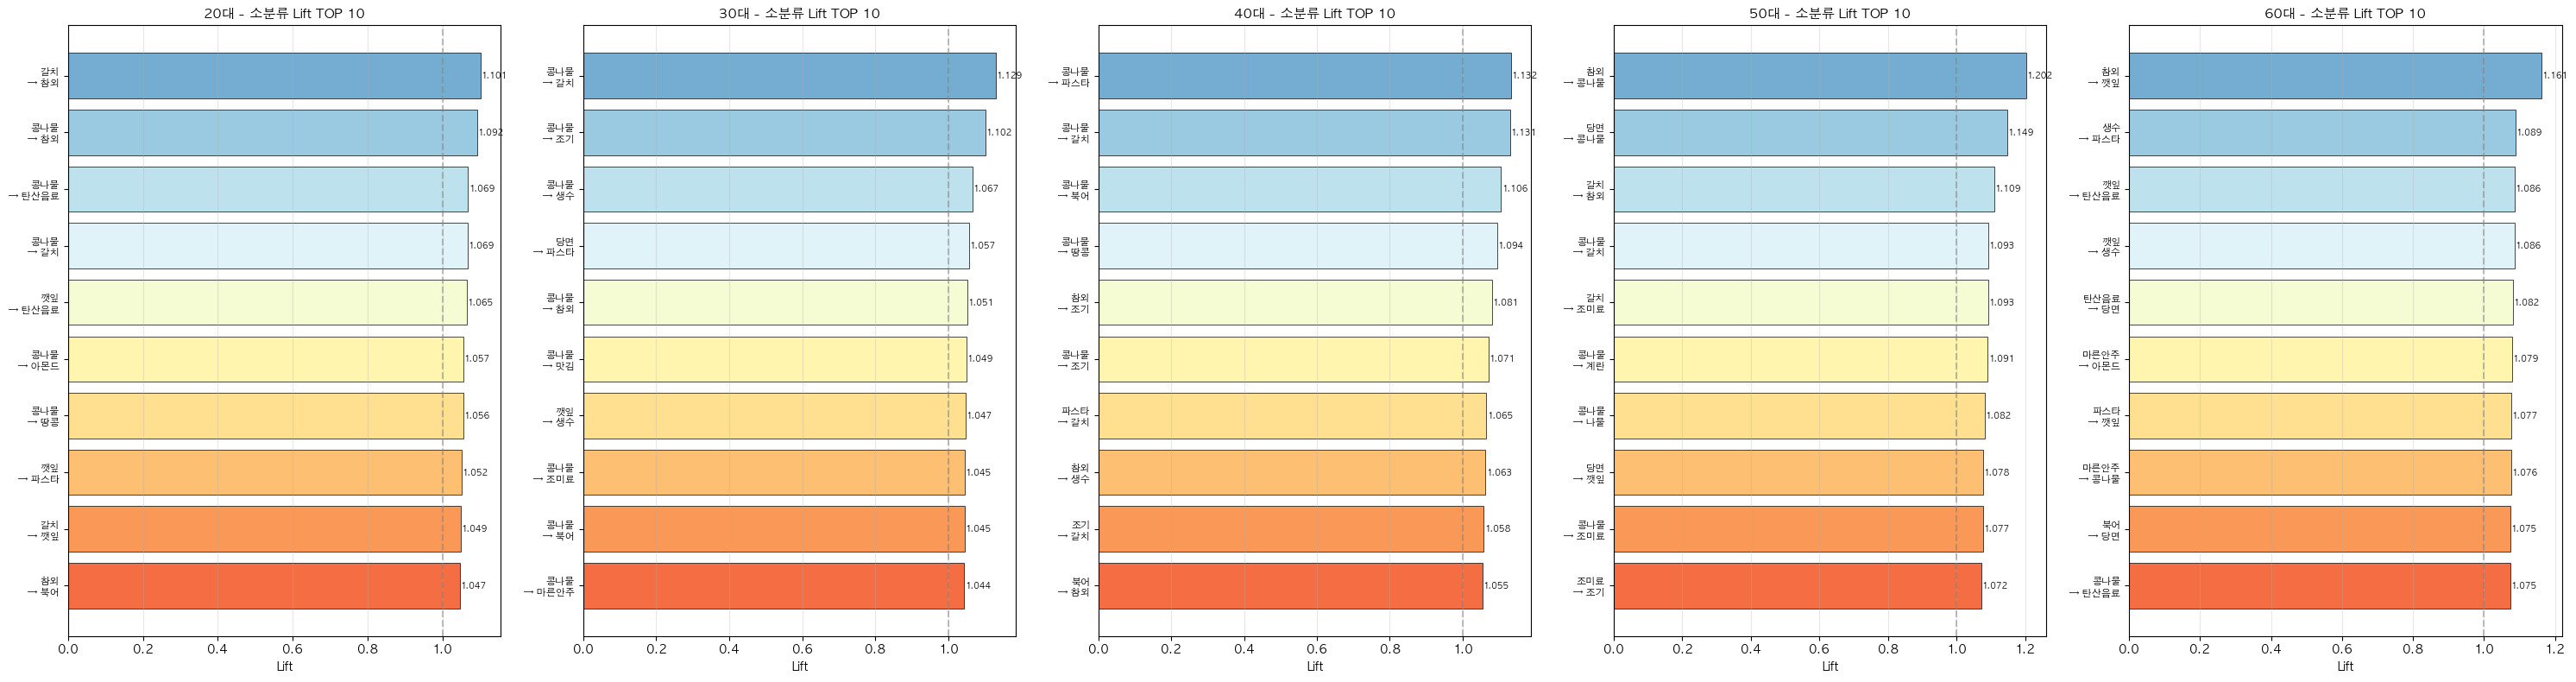


✓ 연령대별 소분류 연관분석 시각화 저장: age_group_small_association.png


In [27]:
# 8. 연령대별 소분류 연관분석 시각화
if age_small_results:
    num_ages = len(age_small_results)
    fig, axes = plt.subplots(1, num_ages, figsize=(6*num_ages, 8))
    
    if num_ages == 1:
        axes = [axes]
    
    for idx, (age_group, rules_age) in enumerate(age_small_results.items()):
        ax = axes[idx]
        top5 = rules_age.head(10)
        
        labels = []
        for x, y in zip(top5['antecedents'], top5['consequents']):
            ant = ', '.join(list(x))
            cons = ', '.join(list(y))
            if len(ant) > 10:
                ant = ant[:10] + '...'
            if len(cons) > 10:
                cons = cons[:10] + '...'
            labels.append(f"{ant}\n→ {cons}")
        
        colors = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, len(top5)))
        bars = ax.barh(range(len(top5)), top5['lift'].values, color=colors, edgecolor='black', linewidth=0.5)
        ax.set_yticks(range(len(top5)))
        ax.set_yticklabels(labels, fontsize=8)
        ax.set_xlabel('Lift', fontsize=10)
        ax.set_title(f'{age_group}대 - 소분류 Lift TOP 10', fontsize=11, fontweight='bold')
        ax.invert_yaxis()
        ax.grid(alpha=0.3, axis='x')
        ax.axvline(x=1, color='gray', linestyle='--', alpha=0.5)
        
        for bar, val in zip(bars, top5['lift'].values):
            ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
                   va='center', fontsize=7, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('age_group_small_association.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✓ 연령대별 소분류 연관분석 시각화 저장: age_group_small_association.png")


In [28]:
# 9. 연령대별 연관상품 추천 요약표
print("=" * 120)
print("【연령대별 연관상품 추천 요약】")
print("=" * 120)
print("(각 연령대에서 Lift가 높은 상위 연관 상품 쌍을 추천 상품으로 제시)")
print()

recommendation_data = []

for age_group in age_groups:
    if age_group in age_small_results:
        rules_age = age_small_results[age_group]
        top_rules = rules_age.head(10)
        
        print(f"\n{'━' * 60}")
        print(f"  {age_group}대 추천 연관상품")
        print(f"{'━' * 60}")
        
        for rank, (_, row) in enumerate(top_rules.iterrows(), 1):
            ant = ', '.join(list(row['antecedents']))
            cons = ', '.join(list(row['consequents']))
            ant_mid = ', '.join([small_to_middle.get(i, '?') for i in list(row['antecedents'])])
            cons_mid = ', '.join([small_to_middle.get(i, '?') for i in list(row['consequents'])])
            
            print(f"  {rank:2d}. {ant}({ant_mid}) 구매 시 → {cons}({cons_mid}) 추천")
            print(f"      Confidence: {row['confidence']:.1%} | Lift: {row['lift']:.4f}")
            
            recommendation_data.append({
                '연령대': f'{age_group}대',
                '순위': rank,
                '상품A': ant,
                '상품A_중분류': ant_mid,
                '상품B': cons,
                '상품B_중분류': cons_mid,
                'Support': round(row['support'], 4),
                'Confidence': round(row['confidence'], 4),
                'Lift': round(row['lift'], 4)
            })

recommendation_df = pd.DataFrame(recommendation_data)
print(f"\n\n{'=' * 120}")
print(f"총 {len(recommendation_df)}개 연관상품 추천 규칙 도출 완료")
print(f"{'=' * 120}")


【연령대별 연관상품 추천 요약】
(각 연령대에서 Lift가 높은 상위 연관 상품 쌍을 추천 상품으로 제시)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  20대 추천 연관상품
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   1. 갈치(수산) 구매 시 → 참외(과일) 추천
      Confidence: 49.7% | Lift: 1.1013
   2. 콩나물(채소) 구매 시 → 참외(과일) 추천
      Confidence: 49.3% | Lift: 1.0924
   3. 콩나물(채소) 구매 시 → 탄산음료(탄산) 추천
      Confidence: 69.2% | Lift: 1.0685
   4. 콩나물(채소) 구매 시 → 갈치(수산) 추천
      Confidence: 64.0% | Lift: 1.0685
   5. 깻잎(채소) 구매 시 → 탄산음료(탄산) 추천
      Confidence: 69.0% | Lift: 1.0654
   6. 콩나물(채소) 구매 시 → 아몬드(곡물) 추천
      Confidence: 88.2% | Lift: 1.0568
   7. 콩나물(채소) 구매 시 → 땅콩(곡물) 추천
      Confidence: 79.6% | Lift: 1.0565
   8. 깻잎(채소) 구매 시 → 파스타(곡물) 추천
      Confidence: 78.2% | Lift: 1.0517
   9. 갈치(수산) 구매 시 → 깻잎(채소) 추천
      Confidence: 62.3% | Lift: 1.0494
  10. 참외(과일) 구매 시 → 북어(수산) 추천
      Confidence: 81.4% | Lift: 1.0472

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  30대 추천 연관상품
━━━━━━━━━━━━━━━━━━━━━━━━━

In [29]:
# 10. 연령대별 고유 연관상품
print("=" * 120)
print("【연령대별 고유 연관상품】")
print("  다른 연령대 대비 해당 연령대에서 Lift가 특별히 높은 규칙")
print("=" * 120)

all_age_rules = []
for age_group, rules_age in age_small_results.items():
    temp = rules_age.copy()
    temp['age_group'] = age_group
    temp['pair_key'] = temp.apply(lambda r: tuple(sorted([tuple(sorted(list(r['antecedents']))), tuple(sorted(list(r['consequents'])))])), axis=1)
    all_age_rules.append(temp)

all_rules_df = pd.concat(all_age_rules, ignore_index=True)

pivot_lift = all_rules_df.pivot_table(index='pair_key', columns='age_group', values='lift', aggfunc='first')

for age_group in age_groups:
    if age_group not in pivot_lift.columns:
        continue
    
    other_ages = [a for a in age_groups if a != age_group and a in pivot_lift.columns]
    if not other_ages:
        continue
    
    pivot_lift[f'{age_group}_diff'] = pivot_lift[age_group] - pivot_lift[other_ages].mean(axis=1)
    
    top_unique = pivot_lift.dropna(subset=[age_group]).nlargest(5, f'{age_group}_diff')
    
    if len(top_unique) > 0:
        print(f"\n【{age_group}대 고유 연관상품 TOP 5】")
        print("-" * 80)
        
        for rank, (pair_key, row) in enumerate(top_unique.iterrows(), 1):
            items_a = ', '.join(list(pair_key[0])) if isinstance(pair_key[0], tuple) else str(pair_key[0])
            items_b = ', '.join(list(pair_key[1])) if isinstance(pair_key[1], tuple) else str(pair_key[1])
            
            lift_val = row[age_group]
            other_avg = row[other_ages].mean()
            diff = row[f'{age_group}_diff']
            
            print(f"  {rank}. {items_a} ↔ {items_b}")
            print(f"     {age_group}대 Lift: {lift_val:.4f} | 타 연령대 평균 Lift: {other_avg:.4f} | 차이: +{diff:.4f}")
    
    pivot_lift.drop(columns=[f'{age_group}_diff'], inplace=True)

print(f"\n{'=' * 120}")


【연령대별 고유 연관상품】
  다른 연령대 대비 해당 연령대에서 Lift가 특별히 높은 규칙

【20대 고유 연관상품 TOP 5】
--------------------------------------------------------------------------------
  1. 갈치 ↔ 참외
     20대 Lift: 1.1013 | 타 연령대 평균 Lift: 1.0038 | 차이: +0.0975
  2. 깻잎 ↔ 탄산음료
     20대 Lift: 1.0654 | 타 연령대 평균 Lift: 1.0237 | 차이: +0.0418
  3. 참외 ↔ 콩나물
     20대 Lift: 1.0924 | 타 연령대 평균 Lift: 1.0528 | 차이: +0.0396
  4. 참외 ↔ 탄산음료
     20대 Lift: 1.0351 | 타 연령대 평균 Lift: 0.9964 | 차이: +0.0387
  5. 콩나물 ↔ 탄산음료
     20대 Lift: 1.0685 | 타 연령대 평균 Lift: 1.0326 | 차이: +0.0360

【30대 고유 연관상품 TOP 5】
--------------------------------------------------------------------------------
  1. 조기 ↔ 콩나물
     30대 Lift: 1.1023 | 타 연령대 평균 Lift: 1.0052 | 차이: +0.0971
  2. 생수 ↔ 콩나물
     30대 Lift: 1.0666 | 타 연령대 평균 Lift: 1.0042 | 차이: +0.0624
  3. 갈치 ↔ 콩나물
     30대 Lift: 1.1294 | 타 연령대 평균 Lift: 1.0710 | 차이: +0.0584
  4. 조기 ↔ 파스타
     30대 Lift: 1.0440 | 타 연령대 평균 Lift: 1.0080 | 차이: +0.0360
  5. 마른안주 ↔ 조기
     30대 Lift: 1.0291 | 타 연령대 평균 Lift: 0.9936 | 차이: +0.0355
